In [42]:
import polars as pl
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import os
from collections import defaultdict
import datetime as dt
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker
sys.path.insert(1, os.path.abspath(".."))
os.chdir(os.path.abspath('..')) # Change the workdir to the parent folder

# ── Visual defaults ───────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
SIRS_COLORS = {0: "#4CAF50", 1: "#FFC107", 2: "#FF9800", 3: "#F44336", 4: "#9C27B0"}

In [19]:
from src.configs.dataconfig import input_output_config
from src.utils.utils import load_df

In [50]:
df_all = load_df(input_output_config.output_path, "df_all.parquet")
df_sirs = load_df(input_output_config.output_path, "df_sirs.parquet")
df_agg = load_df(input_output_config.output_path, "df_agg.parquet")
df_organdysfunction = load_df(input_output_config.output_path, "df_organdysfunction.parquet")
df_sepsis1 = load_df(input_output_config.output_path, "df_sepsis1.parquet")
df_sepsis2 = load_df(input_output_config.output_path, "df_sepsis2.parquet")
df_sepsis3 = load_df(input_output_config.output_path, "df_sepsis3.parquet")
df_septicshock = load_df(input_output_config.output_path, "df_septicshock.parquet")
df_infect = load_df(input_output_config.output_path, "df_infect_long.parquet")

In [106]:
df_sepsis3

EncounterEpicCsn,criterion,infect_dt,suspicion_infection_type,Event_DateTime,last_temp_8h,last_pulse_8h,last_resp_8h,last_sbp_8h,last_map_8h,last_wbc_12h,last_creatinine_12h,last_egfr_12h,last_bilirubin_12h,last_lactate_6h,last_platelets_24h,last_inr_12h,last_aptt_24h,last_gcs_12h,last_vasopressin_24h,last_phenylephrine_24h,last_norepinephrine_24h,last_epinephrine_24h,vent_status_time,vent_status_flag,Baseline_Creatinine,Baseline_eGFR,Baseline_Bilirubin,Baseline_Platelets,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_WBC,cardiovascular_failure_flag,coagulation_failure_flag,platelets50_criteria_flag,aptt_criteria_flag,…,organ_dysfunction_total,Event_DateTime_septicshock,last_temp_8h_septicshock,last_pulse_8h_septicshock,last_resp_8h_septicshock,last_sbp_8h_septicshock,last_map_8h_septicshock,last_wbc_12h_septicshock,last_creatinine_12h_septicshock,last_egfr_12h_septicshock,last_bilirubin_12h_septicshock,last_lactate_6h_septicshock,last_platelets_24h_septicshock,last_inr_12h_septicshock,last_aptt_24h_septicshock,last_gcs_12h_septicshock,last_vasopressin_24h_septicshock,last_phenylephrine_24h_septicshock,last_norepinephrine_24h_septicshock,last_epinephrine_24h_septicshock,vent_status_time_septicshock,vent_status_flag_septicshock,Baseline_Creatinine_septicshock,Baseline_eGFR_septicshock,Baseline_Bilirubin_septicshock,Baseline_Platelets_septicshock,Baseline_SBP_septicshock,Baseline_RespiratoryRate_septicshock,Baseline_PulseRate_septicshock,Baseline_WBC_septicshock,sbp90_flag,sbpdelta40_flag,map65_flag,lactate4_flag,vasopressor_flag,septic_shock_flag,earliest_sepsis3_instance
i64,str,datetime[μs],str,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,…,i64,datetime[μs],f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,datetime[μs]
699476058,"""iv_dt""",2024-05-01 01:31:25,"""IV+Culture""",2024-05-02 03:00:00,98.4,112.0,0.0,null,67.0,11.34,1.43,42.0,1.6,1.5,77.0,1.1,null,3.0,0.04,null,0.01,0.1,2024-04-30 22:00:00,"""Vent on Documentation""",1.413333,49.0,0.7,298.5,120.0,15.0,97.0,8.765,0,1,1,0,…,3,2024-05-03 02:58:02.690,98.4,124.0,16.0,123,85.0,16.28,1.48,41.0,null,0.7,45.0,null,null,3.0,0.04,null,0.06,0.1,2024-04-30 22:00:00,"""Vent on Documentation""",1.413333,49.0,0.7,298.5,120.0,15.0,97.0,8.765,0,0,0,0,1,1,2024-05-01 01:31:25
714445951,"""culture_dt""",2024-11-02 09:27:00,"""IV+Culture""",2024-11-02 14:00:00,97.7,101.0,19.0,94,66.0,5.31,2.07,33.0,0.7,null,102.0,null,null,15.0,0.01,null,0.01,null,2024-11-01 11:41:00,"""O2 Delivery High-Flow""",0.868077,98.538462,0.857143,107.483871,101.0,19.0,110.0,5.735161,0,0,0,0,…,2,2024-11-03 13:55:00,99.4,111.0,20.0,105,65.0,9.29,2.76,24.0,0.9,0.3,99.0,1.1,null,15.0,null,null,0.08,0.01,2024-11-03 11:17:00,"""O2 Delivery High-Flow""",0.868077,98.538462,0.857143,107.483871,101.0,19.0,110.0,5.735161,0,0,0,0,1,1,2024-11-02 09:27:00
714534044,"""iv_dt""",2024-10-26 09:44:38,"""IV+Culture""",2024-10-26 08:00:00,97.9,93.0,18.0,126,null,null,0.99,81.0,null,null,154.0,null,null,14.0,null,null,null,null,null,null,0.8,94.333333,1.266667,186.666667,128.0,null,92.0,6.09,0,0,0,0,…,1,2024-10-27 07:11:00,99.3,85.0,22.0,99,65.0,9.46,1.22,63.0,null,2.3,87.0,null,null,7.0,null,0.2,null,null,2024-10-27 03:01:00,"""O2 Delivery High-Flow""",0.8,94.333333,1.266667,186.666667,128.0,null,92.0,6.09,0,0,0,0,1,1,2024-10-26 08:00:00
717006646,"""lactate_dt""",2024-12-23 08:25:00,"""LACTATE+CULTURE""",2024-12-21 16:00:00,99.9,98.0,10.0,null,68.0,9.4,2.19,33.0,null,1.2,122.0,null,null,15.0,0.04,null,0.1,null,2024-12-20 21:00:00,"""Vent on Documentation""",2.082143,35.416667,0.65,173.0,104.0,16.0,74.0,6.556667,0,0,0,0,…,1,2024-12-22 15:59:00,97.8,93.0,16.0,83,40.0,7.53,1.89,39.0,null,1.0,96.0,null,null,15.0,null,null,null,0.02,2024-12-20 21:00:00,"""Vent on Documentation""",2.082143,35.416667,0.65,173.0,104.0,16.

# Organ dysfunction

In [97]:
df2 = df_organdysfunction.join(
    df_infect,
    on=["EncounterEpicCsn"],
	how='left',
).filter(
    (pl.col("Event_DateTime") >= pl.col("infect_dt") - pl.duration(hours=72))&
    (pl.col("Event_DateTime") <= pl.col("infect_dt") + pl.duration(hours=72))
).sort(["EncounterEpicCsn", "Event_DateTime"])\
.select(
    ["EncounterEpicCsn",
	"Event_DateTime",
	"infect_dt",
	"criterion",
	"suspicion_infection_type",
	"organ_dysfunction_total",
	]+[
        c for c in df_organdysfunction.columns if c.endswith('_flag')
	]
)

In [98]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

# Organ systems we analyze — order matters for consistent plotting
ORGAN_SYSTEMS = [
    "cardiovascular_failure_flag",
    "coagulation_failure_flag",
    "pulmonary_failure_flag",
    "renal_failure_flag",
    "hepatic_failure_flag",
    "neurological_failure_flag",
]

# Clean labels for plots
ORGAN_LABELS = {
    "cardiovascular_failure_flag": "Cardiovascular",
    "coagulation_failure_flag":    "Coagulation",
    "pulmonary_failure_flag":      "Pulmonary",
    "renal_failure_flag":          "Renal",
    "hepatic_failure_flag":        "Hepatic",
    "neurological_failure_flag":   "Neurological",
}

# Color per organ system
ORGAN_COLORS = {
    "cardiovascular_failure_flag": "#E53935",
    "coagulation_failure_flag":    "#8E24AA",
    "pulmonary_failure_flag":      "#1E88E5",
    "renal_failure_flag":          "#00897B",
    "hepatic_failure_flag":        "#F4511E",
    "neurological_failure_flag":   "#FFB300",
}

# Dysfunction total states
DYSFUNC_COLORS = {
    0: "#4CAF50", 1: "#FFC107", 2: "#FF9800",
    3: "#F44336", 4: "#9C27B0", 5: "#3F51B5", 6: "#212121"
}

In [99]:
# ── Episode Assignment (identical to Sepsis-1) ────────────────────
df2 = df2.sort(["EncounterEpicCsn", "Event_DateTime"])

infection_anchors = (
    df2.select(["EncounterEpicCsn", "infect_dt"])
    .unique()
    .sort(["EncounterEpicCsn", "infect_dt"])
    .rename({"infect_dt": "episode_start"})
)

df2 = df2.join_asof(
    infection_anchors,
    left_on="Event_DateTime",
    right_on="episode_start",
    by="EncounterEpicCsn",
    strategy="backward"
).filter(
    pl.col("episode_start").is_not_null()
).with_columns(
    pl.concat_str(
        [pl.col("EncounterEpicCsn").cast(pl.Utf8),
         pl.col("episode_start").cast(pl.Utf8)],
        separator="_"
    ).alias("episode_id")
)

# Cast pulmonary and neurological to Int32 for consistency
df2 = df2.with_columns([
    pl.col("pulmonary_failure_flag").cast(pl.Int32),
    pl.col("neurological_failure_flag").cast(pl.Int32),
])

print(df2.schema)
print(df2.head())

/tmp/ipykernel_2501218/1513359817.py:11: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df2 = df2.join_asof(


Schema([('EncounterEpicCsn', Int64), ('Event_DateTime', Datetime(time_unit='us', time_zone=None)), ('infect_dt', Datetime(time_unit='us', time_zone=None)), ('criterion', String), ('suspicion_infection_type', String), ('organ_dysfunction_total', Int64), ('vent_status_flag', String), ('cardiovascular_failure_flag', Int32), ('coagulation_failure_flag', Int32), ('platelets50_criteria_flag', Int32), ('aptt_criteria_flag', Int32), ('platelets100_criteria_flag', Int32), ('inr_criteria_flag', Int32), ('pulmonary_failure_flag', Int32), ('renal_failure_flag', Int32), ('hepatic_failure_flag', Int32), ('neurological_failure_flag', Int32), ('episode_start', Datetime(time_unit='us', time_zone=None)), ('episode_id', String)])
shape: (5, 19)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Encounter ┆ Event_Dat ┆ infect_dt ┆ criterion ┆ … ┆ hepatic_f ┆ neurologi ┆ episode_s ┆ episode_ │
│ EpicCsn   ┆ eTime     ┆ ---       ┆ ---       ┆   ┆ ailure_f

In [100]:
def cohort_summary_s2(df: pl.DataFrame) -> pl.DataFrame:
    n_encounters = df["EncounterEpicCsn"].n_unique()
    n_episodes   = df["episode_id"].n_unique()
    n_events     = len(df)

    events_per_episode = (
        df.group_by("episode_id")
        .agg(pl.len().alias("n_events"))
        ["n_events"]
    )

    first_dysfunc = (
        df.sort(["episode_id", "Event_DateTime"])
        .group_by("episode_id")
        .agg(pl.col("organ_dysfunction_total").first().alias("first_dysfunc"))
        ["first_dysfunc"]
    )

    peak_dysfunc = (
        df.group_by("episode_id")
        .agg(pl.col("organ_dysfunction_total").max().alias("peak_dysfunc"))
        ["peak_dysfunc"]
    )

    # ── Cast everything to string to avoid mixed-type column error ─
    summary = pl.DataFrame({
        "Metric": [
            "Total Encounters",
            "Total Infection Episodes",
            "Total Events",
            "Median Events per Episode",
            "P25 Events per Episode",
            "P75 Events per Episode",
            "Median Organ Dysfunctions at Suspicion (t=0)",
            "Median Peak Organ Dysfunctions per Episode",
            "Episodes with >= 1 Organ Dysfunction",
            "Episodes with >= 2 Organ Dysfunctions",
        ],
        "Value": [
            str(n_encounters),
            str(n_episodes),
            str(n_events),
            f"{events_per_episode.median():.1f}",
            f"{events_per_episode.quantile(0.25):.1f}",
            f"{events_per_episode.quantile(0.75):.1f}",
            f"{first_dysfunc.median():.2f}",
            f"{peak_dysfunc.median():.2f}",
            str(int((peak_dysfunc >= 1).sum())),
            str(int((peak_dysfunc >= 2).sum())),
        ]
    })
    return summary
summary_df = cohort_summary_s2(df2)
print(summary_df)

shape: (10, 2)
┌─────────────────────────────────┬─────────┐
│ Metric                          ┆ Value   │
│ ---                             ┆ ---     │
│ str                             ┆ str     │
╞═════════════════════════════════╪═════════╡
│ Total Encounters                ┆ 3957    │
│ Total Infection Episodes        ┆ 10859   │
│ Total Events                    ┆ 4885880 │
│ Median Events per Episode       ┆ 132.0   │
│ P25 Events per Episode          ┆ 32.0    │
│ P75 Events per Episode          ┆ 672.0   │
│ Median Organ Dysfunctions at S… ┆ 0.00    │
│ Median Peak Organ Dysfunctions… ┆ 1.00    │
│ Episodes with >= 1 Organ Dysfu… ┆ 5726    │
│ Episodes with >= 2 Organ Dysfu… ┆ 2513    │
└─────────────────────────────────┴─────────┘


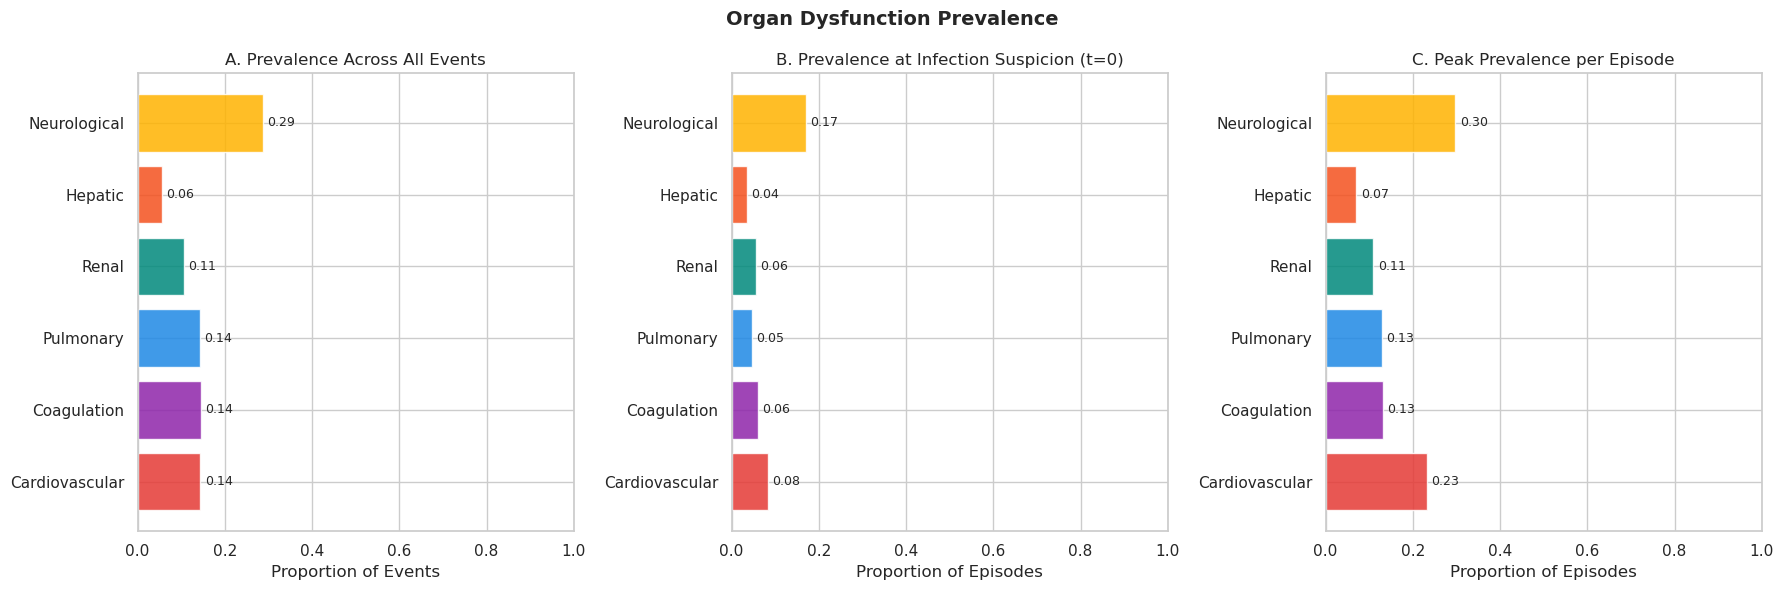


Organ Dysfunction Prevalence Table:
shape: (6, 4)
┌────────────────┬────────────┬────────────────────┬──────────────────┐
│ Organ System   ┆ All Events ┆ At Suspicion (t=0) ┆ Peak per Episode │
│ ---            ┆ ---        ┆ ---                ┆ ---              │
│ str            ┆ f64        ┆ f64                ┆ f64              │
╞════════════════╪════════════╪════════════════════╪══════════════════╡
│ Cardiovascular ┆ 0.144      ┆ 0.083              ┆ 0.232            │
│ Coagulation    ┆ 0.145      ┆ 0.059              ┆ 0.131            │
│ Pulmonary      ┆ 0.143      ┆ 0.047              ┆ 0.13             │
│ Renal          ┆ 0.107      ┆ 0.056              ┆ 0.11             │
│ Hepatic        ┆ 0.056      ┆ 0.035              ┆ 0.071            │
│ Neurological   ┆ 0.288      ┆ 0.171              ┆ 0.297            │
└────────────────┴────────────┴────────────────────┴──────────────────┘


In [101]:
def plot_organ_prevalence(df: pl.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Organ Dysfunction Prevalence", fontsize=14, fontweight="bold")

    organ_names  = [ORGAN_LABELS[o] for o in ORGAN_SYSTEMS]
    organ_colors = [ORGAN_COLORS[o] for o in ORGAN_SYSTEMS]

    # ── Panel A: Prevalence across ALL events ─────────────────────
    # What fraction of all measurements show each organ failing?
    event_prev = [
        df[organ].mean()
        for organ in ORGAN_SYSTEMS
    ]
    axes[0].barh(organ_names, event_prev, color=organ_colors, alpha=0.85)
    axes[0].set_xlabel("Proportion of Events")
    axes[0].set_title("A. Prevalence Across All Events")
    axes[0].set_xlim(0, 1)
    for i, v in enumerate(event_prev):
        axes[0].text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

    # ── Panel B: Prevalence at infection suspicion (t=0) ──────────
    # What fraction of episodes had each organ failing at first event?
    first_events = (
        df.sort(["episode_id", "Event_DateTime"])
        .group_by("episode_id")
        .agg([pl.col(o).first().alias(o) for o in ORGAN_SYSTEMS])
    )
    t0_prev = [first_events[organ].mean() for organ in ORGAN_SYSTEMS]

    axes[1].barh(organ_names, t0_prev, color=organ_colors, alpha=0.85)
    axes[1].set_xlabel("Proportion of Episodes")
    axes[1].set_title("B. Prevalence at Infection Suspicion (t=0)")
    axes[1].set_xlim(0, 1)
    for i, v in enumerate(t0_prev):
        axes[1].text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

    # ── Panel C: Peak prevalence per episode ──────────────────────
    # What fraction of episodes had each organ fail at any point?
    peak_events = (
        df.group_by("episode_id")
        .agg([pl.col(o).max().alias(o) for o in ORGAN_SYSTEMS])
    )
    peak_prev = [peak_events[organ].mean() for organ in ORGAN_SYSTEMS]

    axes[2].barh(organ_names, peak_prev, color=organ_colors, alpha=0.85)
    axes[2].set_xlabel("Proportion of Episodes")
    axes[2].set_title("C. Peak Prevalence per Episode")
    axes[2].set_xlim(0, 1)
    for i, v in enumerate(peak_prev):
        axes[2].text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    # Summary table
    prev_table = pl.DataFrame({
        "Organ System":       organ_names,
        "All Events":         [round(v, 3) for v in event_prev],
        "At Suspicion (t=0)": [round(v, 3) for v in t0_prev],
        "Peak per Episode":   [round(v, 3) for v in peak_prev],
    })
    print("\nOrgan Dysfunction Prevalence Table:")
    print(prev_table)

plot_organ_prevalence(df2)

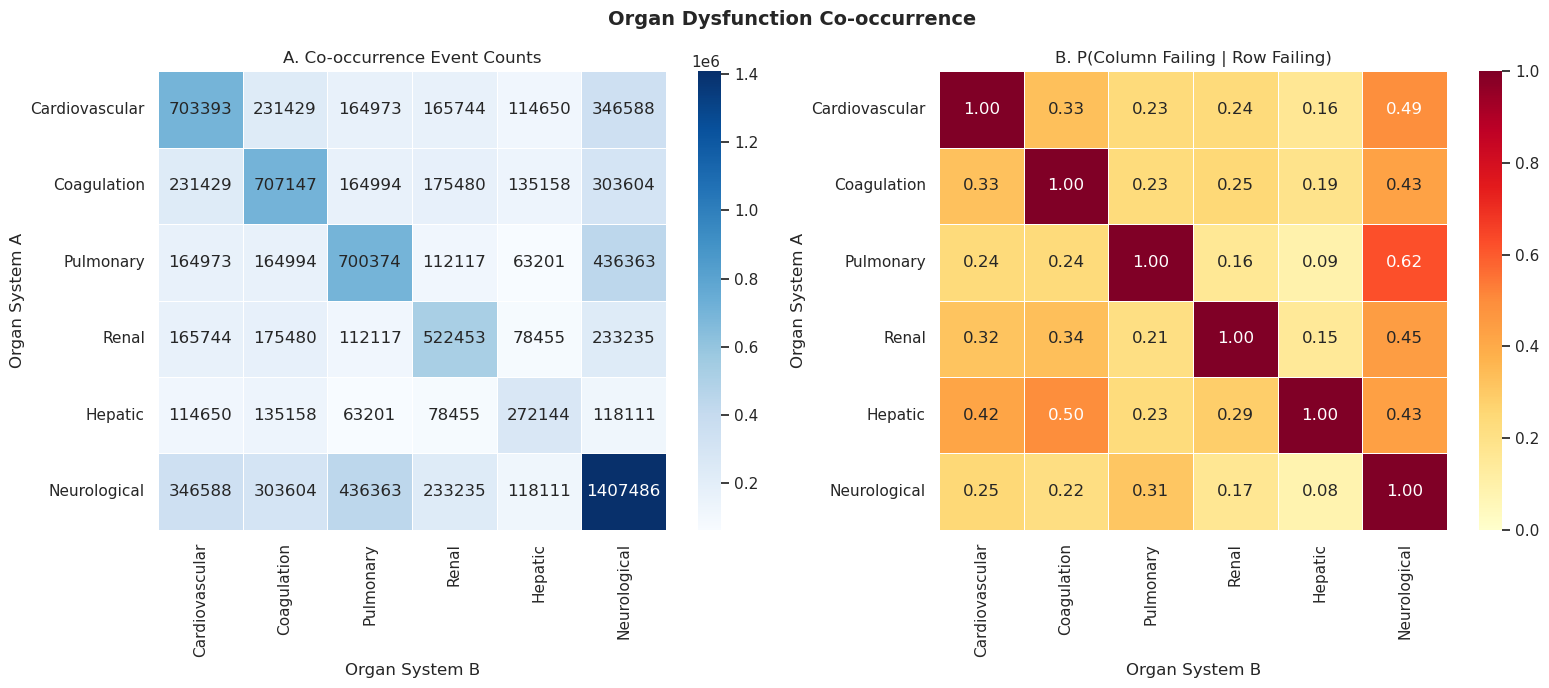

In [102]:
def plot_cooccurrence_matrix(df: pl.DataFrame):
    """
    For each pair of organ systems, compute the fraction of events
    where both are simultaneously flagged as 1.
    Normalized by the prevalence of the less common organ — this
    gives P(B failing | A failing), not raw co-occurrence.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Organ Dysfunction Co-occurrence", fontsize=14, fontweight="bold")

    n_organs = len(ORGAN_SYSTEMS)
    labels   = [ORGAN_LABELS[o] for o in ORGAN_SYSTEMS]

    # ── Raw co-occurrence count matrix ────────────────────────────
    raw_matrix  = np.zeros((n_organs, n_organs))
    cond_matrix = np.zeros((n_organs, n_organs))

    organ_data = {o: df[o].to_numpy() for o in ORGAN_SYSTEMS}

    for i, org_i in enumerate(ORGAN_SYSTEMS):
        for j, org_j in enumerate(ORGAN_SYSTEMS):
            both     = int(((organ_data[org_i] == 1) & (organ_data[org_j] == 1)).sum())
            org_i_on = int((organ_data[org_i] == 1).sum())

            raw_matrix[i][j]  = both
            # P(org_j = 1 | org_i = 1)
            cond_matrix[i][j] = both / org_i_on if org_i_on > 0 else 0

    # Panel A: Raw counts
    sns.heatmap(
        raw_matrix.astype(int),
        annot=True, fmt="d",
        xticklabels=labels, yticklabels=labels,
        cmap="Blues", ax=axes[0],
        linewidths=0.5
    )
    axes[0].set_title("A. Co-occurrence Event Counts")
    axes[0].set_xlabel("Organ System B")
    axes[0].set_ylabel("Organ System A")

    # Panel B: Conditional probabilities P(B=1 | A=1)
    sns.heatmap(
        cond_matrix,
        annot=True, fmt=".2f",
        xticklabels=labels, yticklabels=labels,
        cmap="YlOrRd", ax=axes[1],
        linewidths=0.5,
        vmin=0, vmax=1
    )
    axes[1].set_title("B. P(Column Failing | Row Failing)")
    axes[1].set_xlabel("Organ System B")
    axes[1].set_ylabel("Organ System A")

    plt.tight_layout()
    plt.show()

plot_cooccurrence_matrix(df2)

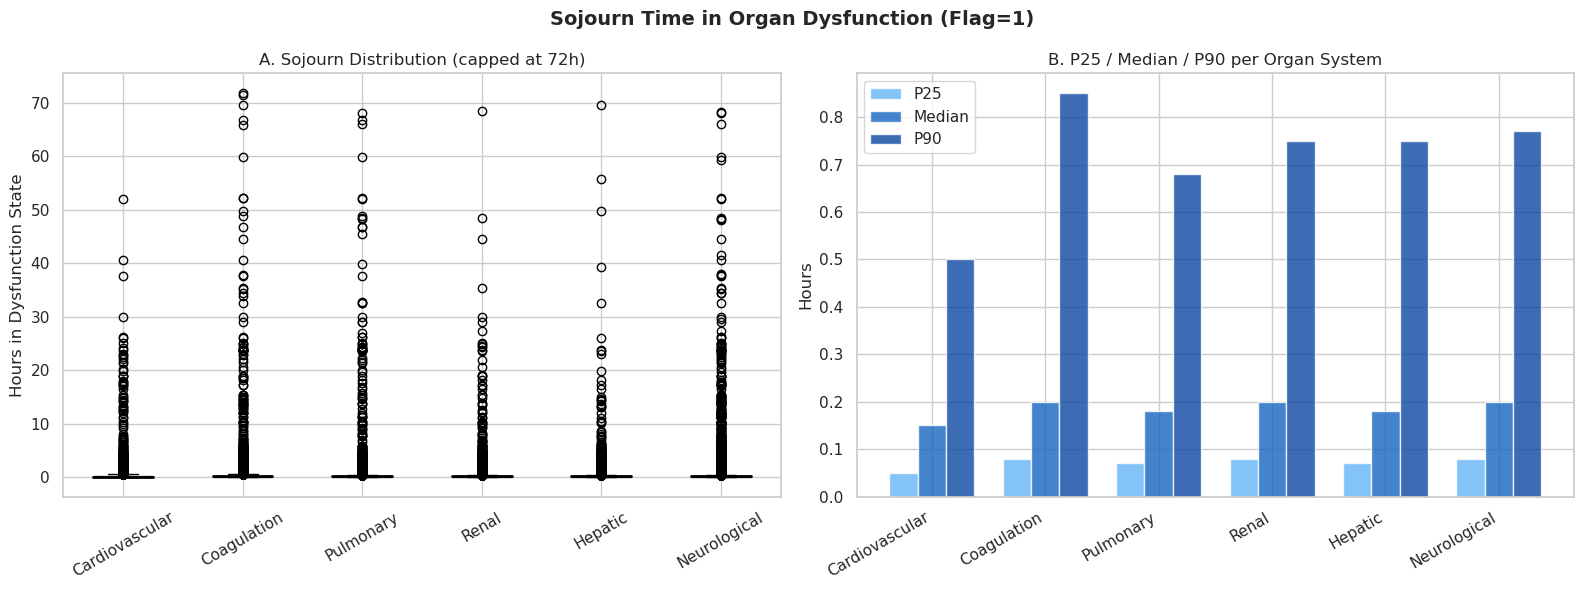


Organ Sojourn Time Summary:
shape: (6, 6)
┌────────────────┬──────────┬────────────┬─────────┬─────────┬─────────┐
│ Organ System   ┆ N Events ┆ Median (h) ┆ P25 (h) ┆ P75 (h) ┆ P90 (h) │
│ ---            ┆ ---      ┆ ---        ┆ ---     ┆ ---     ┆ ---     │
│ str            ┆ i64      ┆ f64        ┆ f64     ┆ f64     ┆ f64     │
╞════════════════╪══════════╪════════════╪═════════╪═════════╪═════════╡
│ Cardiovascular ┆ 117269   ┆ 0.15       ┆ 0.05    ┆ 0.25    ┆ 0.5     │
│ Coagulation    ┆ 139502   ┆ 0.2        ┆ 0.08    ┆ 0.3     ┆ 0.85    │
│ Pulmonary      ┆ 154626   ┆ 0.18       ┆ 0.07    ┆ 0.25    ┆ 0.68    │
│ Renal          ┆ 95281    ┆ 0.2        ┆ 0.08    ┆ 0.25    ┆ 0.75    │
│ Hepatic        ┆ 50311    ┆ 0.18       ┆ 0.07    ┆ 0.25    ┆ 0.75    │
│ Neurological   ┆ 277764   ┆ 0.2        ┆ 0.08    ┆ 0.25    ┆ 0.77    │
└────────────────┴──────────┴────────────┴─────────┴─────────┴─────────┘


In [103]:
def compute_organ_sojourn(df: pl.DataFrame) -> pl.DataFrame:
    """
    For each organ system flag, compute sojourn time in the
    active (=1) state. We only care about how long a dysfunction
    persists once triggered — not how long a patient stays healthy.
    """
    df_sorted = df.sort(["episode_id", "Event_DateTime"])

    # Add next event time within episode
    df_sorted = df_sorted.with_columns(
        pl.col("Event_DateTime")
          .shift(-1)
          .over("episode_id")
          .alias("next_event_dt")
    ).with_columns(
        (pl.col("next_event_dt") - pl.col("Event_DateTime"))
          .dt.total_seconds()
          .truediv(3600)
          .alias("sojourn_hours")
    ).filter(
        pl.col("sojourn_hours").is_not_null() &
        (pl.col("sojourn_hours") > 0)
    )

    return df_sorted


def plot_organ_sojourn(df_sojourn: pl.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Sojourn Time in Organ Dysfunction (Flag=1)", fontsize=14, fontweight="bold")

    stats_rows = []
    data_for_box = {}

    CAP_HOURS = 72  # longer cap than SIRS — organ dysfunctions persist longer

    for organ in ORGAN_SYSTEMS:
        # Only events where this organ IS failing
        subset = df_sojourn.filter(
            (pl.col(organ) == 1) &
            (pl.col("sojourn_hours") <= CAP_HOURS)
        )["sojourn_hours"]

        if len(subset) == 0:
            continue

        label = ORGAN_LABELS[organ]
        data_for_box[label] = subset.to_list()

        stats_rows.append({
            "Organ System": label,
            "N Events":     len(subset),
            "Median (h)":   round(float(subset.median()), 2),
            "P25 (h)":      round(float(subset.quantile(0.25)), 2),
            "P75 (h)":      round(float(subset.quantile(0.75)), 2),
            "P90 (h)":      round(float(subset.quantile(0.90)), 2),
        })

    # Panel A: Boxplot
    bp = axes[0].boxplot(
        list(data_for_box.values()),
        labels=list(data_for_box.keys()),
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
    for patch, organ in zip(bp["boxes"], ORGAN_SYSTEMS):
        patch.set_facecolor(ORGAN_COLORS[organ])
        patch.set_alpha(0.7)

    axes[0].set_title(f"A. Sojourn Distribution (capped at {CAP_HOURS}h)")
    axes[0].set_ylabel("Hours in Dysfunction State")
    axes[0].tick_params(axis='x', rotation=30)

    # Panel B: P25 / Median / P90 grouped bars
    organ_names = [r["Organ System"] for r in stats_rows]
    medians     = [r["Median (h)"]   for r in stats_rows]
    p25         = [r["P25 (h)"]      for r in stats_rows]
    p90         = [r["P90 (h)"]      for r in stats_rows]
    x           = np.arange(len(organ_names))
    width       = 0.25

    axes[1].bar(x - width, p25,     width, label="P25",    alpha=0.8, color="#64B5F6")
    axes[1].bar(x,         medians, width, label="Median", alpha=0.8, color="#1565C0")
    axes[1].bar(x + width, p90,     width, label="P90",    alpha=0.8, color="#0D47A1")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(organ_names, rotation=30, ha="right")
    axes[1].set_ylabel("Hours")
    axes[1].set_title("B. P25 / Median / P90 per Organ System")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    stats_df = pl.DataFrame(stats_rows)
    print("\nOrgan Sojourn Time Summary:")
    print(stats_df)
    return stats_df


df2_sojourn = compute_organ_sojourn(df2)
sojourn_stats2 = plot_organ_sojourn(df2_sojourn)

shape: (221_987, 2)
┌─────────────────────────┬──────────────┐
│ organ_dysfunction_total ┆ next_dysfunc │
│ ---                     ┆ ---          │
│ i64                     ┆ i64          │
╞═════════════════════════╪══════════════╡
│ 4                       ┆ 3            │
│ 3                       ┆ 4            │
│ 4                       ┆ 3            │
│ 3                       ┆ 1            │
│ 0                       ┆ 1            │
│ …                       ┆ …            │
│ 2                       ┆ 1            │
│ 1                       ┆ 2            │
│ 2                       ┆ 3            │
│ 3                       ┆ 2            │
│ 2                       ┆ 1            │
└─────────────────────────┴──────────────┘


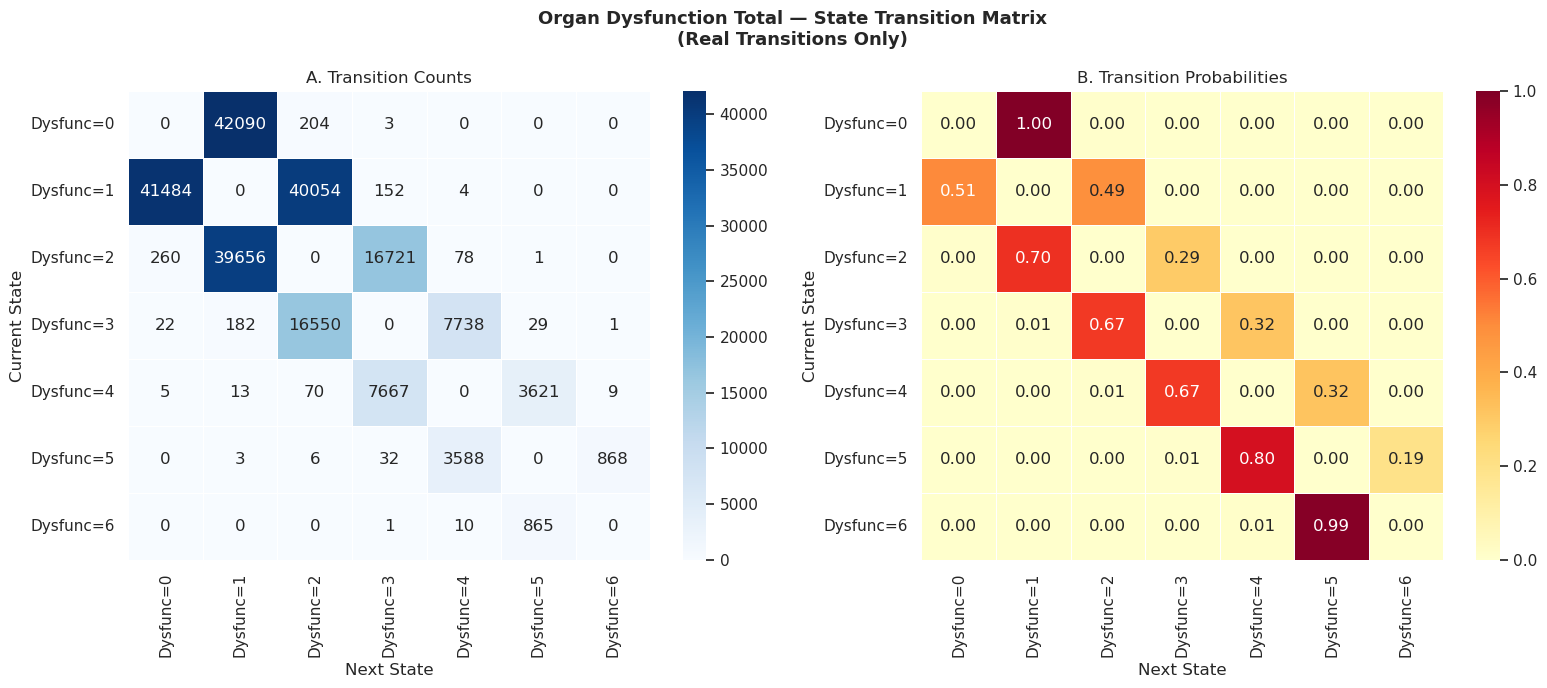


Transition Summary (real transitions only):
From             →D=0   →D=1   →D=2   →D=3   →D=4   →D=5   →D=6 
Dysfunc=0        0.00    1.00    0.00    0.00    0.00    0.00    0.00   (n=42297)
Dysfunc=1        0.51    0.00    0.49    0.00    0.00    0.00    0.00   (n=81694)
Dysfunc=2        0.00    0.70    0.00    0.29    0.00    0.00    0.00   (n=56716)
Dysfunc=3        0.00    0.01    0.67    0.00    0.32    0.00    0.00   (n=24522)
Dysfunc=4        0.00    0.00    0.01    0.67    0.00    0.32    0.00   (n=11385)
Dysfunc=5        0.00    0.00    0.00    0.01    0.80    0.00    0.19   (n=4497)
Dysfunc=6        0.00    0.00    0.00    0.00    0.01    0.99    0.00   (n=876)


In [104]:
def compute_dysfunc_transitions(df: pl.DataFrame):
    df_sorted = df.sort(["episode_id", "Event_DateTime"])

    transitions = df_sorted.with_columns(
        pl.col("organ_dysfunction_total")
          .shift(-1)
          .over("episode_id")
          .alias("next_dysfunc")
    ).filter(
        pl.col("next_dysfunc").is_not_null()
    ).filter(
        # Only real transitions
        pl.col("organ_dysfunction_total") != pl.col("next_dysfunc")
    ).select(["organ_dysfunction_total", "next_dysfunc"])

    # Max possible dysfunction = 6 organ systems
    n_states     = 7  # 0 through 6
    count_matrix = np.zeros((n_states, n_states), dtype=int)
    print(transitions)

    for row in transitions.iter_rows():
        curr, nxt = int(row[0]), int(row[1])
        if 0 <= curr < n_states and 0 <= nxt < n_states:
            count_matrix[curr][nxt] += 1

    row_sums = count_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    prob_matrix = count_matrix / row_sums

    return count_matrix, prob_matrix


def plot_dysfunc_transitions(count_matrix, prob_matrix):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Organ Dysfunction Total — State Transition Matrix\n(Real Transitions Only)",
                 fontsize=13, fontweight="bold")

    labels = [f"Dysfunc={i}" for i in range(7)]

    sns.heatmap(
        count_matrix,
        annot=True, fmt="d",
        xticklabels=labels, yticklabels=labels,
        cmap="Blues", ax=axes[0], linewidths=0.5
    )
    axes[0].set_title("A. Transition Counts")
    axes[0].set_xlabel("Next State")
    axes[0].set_ylabel("Current State")

    sns.heatmap(
        prob_matrix,
        annot=True, fmt=".2f",
        xticklabels=labels, yticklabels=labels,
        cmap="YlOrRd", ax=axes[1], linewidths=0.5,
        vmin=0, vmax=1
    )
    axes[1].set_title("B. Transition Probabilities")
    axes[1].set_xlabel("Next State")
    axes[1].set_ylabel("Current State")

    plt.tight_layout()
    plt.show()

    print("\nTransition Summary (real transitions only):")
    print(f"{'From':<15}", end="")
    for i in range(7):
        print(f"  →D={i} ", end="")
    print()
    for i, row in enumerate(prob_matrix):
        if count_matrix[i].sum() == 0:
            continue
        print(f"Dysfunc={i:<6}", end="")
        for p in row:
            print(f"   {p:.2f} ", end="")
        print(f"  (n={count_matrix[i].sum()})")


count_m2, prob_m2 = compute_dysfunc_transitions(df2)
plot_dysfunc_transitions(count_m2, prob_m2)

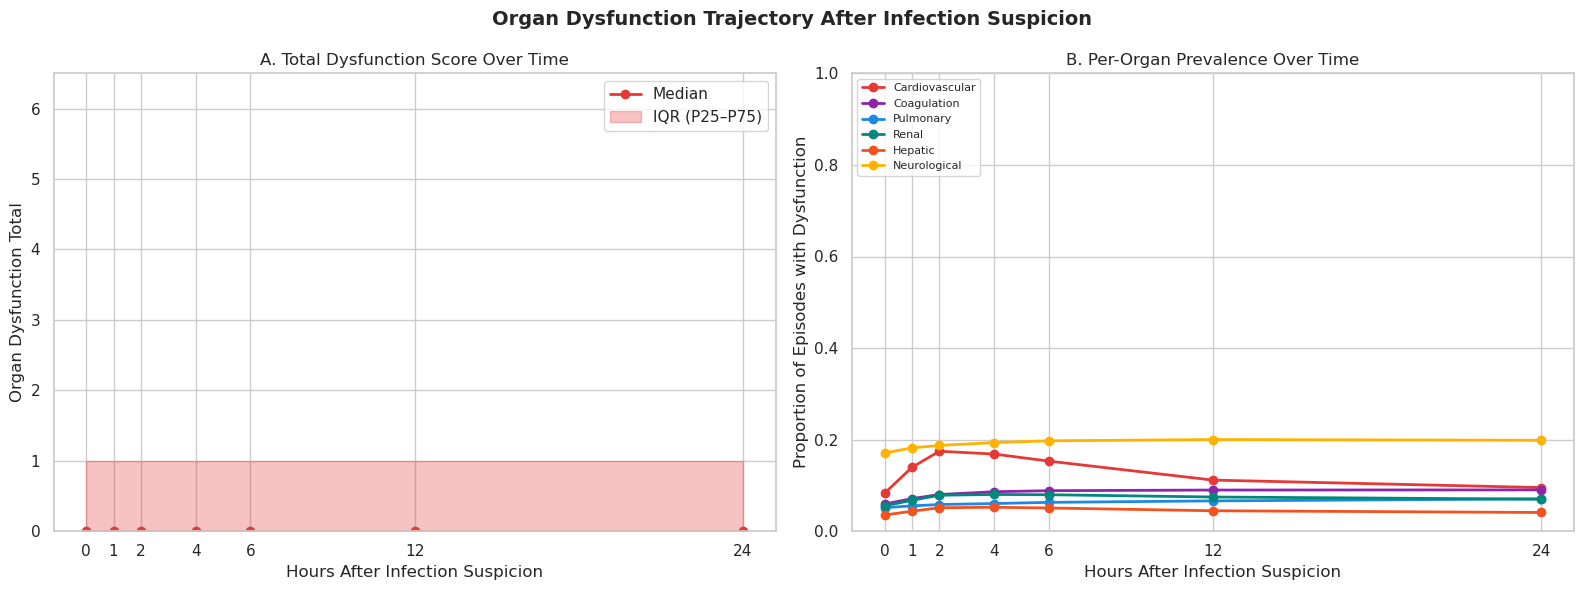


Median Organ Dysfunction Total at Each Timepoint:
shape: (7, 4)
┌───────────┬────────┬─────┬─────┐
│ timepoint ┆ median ┆ p25 ┆ p75 │
│ ---       ┆ ---    ┆ --- ┆ --- │
│ i64       ┆ f64    ┆ f64 ┆ f64 │
╞═══════════╪════════╪═════╪═════╡
│ 0         ┆ 0.0    ┆ 0.0 ┆ 1.0 │
│ 1         ┆ 0.0    ┆ 0.0 ┆ 1.0 │
│ 2         ┆ 0.0    ┆ 0.0 ┆ 1.0 │
│ 4         ┆ 0.0    ┆ 0.0 ┆ 1.0 │
│ 6         ┆ 0.0    ┆ 0.0 ┆ 1.0 │
│ 12        ┆ 0.0    ┆ 0.0 ┆ 1.0 │
│ 24        ┆ 0.0    ┆ 0.0 ┆ 1.0 │
└───────────┴────────┴─────┴─────┘


In [105]:
def plot_dysfunc_trajectory(df: pl.DataFrame):
    TIMEPOINTS_HOURS = [0, 1, 2, 4, 6, 12, 24]

    df = df.with_columns(
        ((pl.col("Event_DateTime") - pl.col("episode_start"))
         .dt.total_seconds()
         .truediv(3600))
        .alias("hours_since_suspicion")
    )

    # ── Build two record sets ──────────────────────────────────────
    # (a) organ_dysfunction_total at each timepoint
    # (b) each organ flag at each timepoint
    total_records = []
    organ_records = []

    for episode, group in df.sort("Event_DateTime").group_by("episode_id"):
        group  = group.sort("hours_since_suspicion")
        times  = group["hours_since_suspicion"].to_list()
        totals = group["organ_dysfunction_total"].to_list()
        organ_vals = {o: group[o].to_list() for o in ORGAN_SYSTEMS}

        for tp in TIMEPOINTS_HOURS:
            candidates = [i for i, t in enumerate(times) if t <= tp]
            if not candidates:
                continue
            last_idx = candidates[-1]

            total_records.append({
                "timepoint": tp,
                "organ_dysfunction_total": totals[last_idx]
            })
            for o in ORGAN_SYSTEMS:
                organ_records.append({
                    "timepoint": tp,
                    "organ": ORGAN_LABELS[o],
                    "flag": organ_vals[o][last_idx]
                })

    total_df = pl.DataFrame(total_records)
    organ_df = pl.DataFrame(organ_records)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Organ Dysfunction Trajectory After Infection Suspicion",
                 fontsize=14, fontweight="bold")

    # ── Panel A: Median total dysfunction over time ───────────────
    stats = (
        total_df.group_by("timepoint")
        .agg([
            pl.col("organ_dysfunction_total").median().alias("median"),
            pl.col("organ_dysfunction_total").quantile(0.25).alias("p25"),
            pl.col("organ_dysfunction_total").quantile(0.75).alias("p75"),
        ])
        .sort("timepoint")
    )

    tps     = stats["timepoint"].to_list()
    medians = stats["median"].to_list()
    p25     = stats["p25"].to_list()
    p75     = stats["p75"].to_list()

    axes[0].plot(tps, medians, marker="o", color="#E53935", linewidth=2, label="Median")
    axes[0].fill_between(tps, p25, p75, alpha=0.3, color="#E53935", label="IQR (P25–P75)")
    axes[0].set_xticks(TIMEPOINTS_HOURS)
    axes[0].set_xlabel("Hours After Infection Suspicion")
    axes[0].set_ylabel("Organ Dysfunction Total")
    axes[0].set_title("A. Total Dysfunction Score Over Time")
    axes[0].legend()
    axes[0].set_ylim(0, 6.5)

    # ── Panel B: Prevalence of each organ flag over time ──────────
    organ_prev = (
        organ_df.group_by(["timepoint", "organ"])
        .agg(pl.col("flag").mean().alias("prevalence"))
        .sort(["organ", "timepoint"])
    )

    for organ in ORGAN_LABELS.values():
        subset = organ_prev.filter(pl.col("organ") == organ)
        color  = [v for k, v in ORGAN_COLORS.items() if ORGAN_LABELS[k] == organ][0]
        axes[1].plot(
            subset["timepoint"].to_list(),
            subset["prevalence"].to_list(),
            marker="o", linewidth=2,
            label=organ, color=color
        )

    axes[1].set_xticks(TIMEPOINTS_HOURS)
    axes[1].set_xlabel("Hours After Infection Suspicion")
    axes[1].set_ylabel("Proportion of Episodes with Dysfunction")
    axes[1].set_title("B. Per-Organ Prevalence Over Time")
    axes[1].legend(fontsize=8, loc="upper left")
    axes[1].set_ylim(0, 1)

    plt.tight_layout()
    plt.show()

    print("\nMedian Organ Dysfunction Total at Each Timepoint:")
    print(stats)


plot_dysfunc_trajectory(df2)

# SIRS analysis

In [35]:
df_sirs_infect_72hrs = df_sirs.join(
    df_infect,
    how='left',
	on=['EncounterEpicCsn']
).filter(
    (pl.col("infect_dt") <= pl.col("Event_DateTime") + pl.duration(hours=72))&
	(pl.col("infect_dt") >= pl.col("Event_DateTime") - pl.duration(hours=72))
).select(
    "EncounterEpicCsn", "criterion", "infect_dt", "suspicion_infection_type", "Event_DateTime", "WBC_Abnormal_Flag", "Temp_Abnormal_Flag", "Resp_Rate_High_Flag", "Pule_High_Flag", "sirs_score"
).filter(
    pl.col("EncounterEpicCsn").is_in(df_sepsis1["EncounterEpicCsn"].unique())
).sort(["EncounterEpicCsn", "Event_DateTime"])

/tmp/ipykernel_2501218/1615272936.py:10: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  ).filter(


In [36]:
df_sirs_infect_72hrs.schema

Schema([('EncounterEpicCsn', Int64),
        ('criterion', String),
        ('infect_dt', Datetime(time_unit='us', time_zone=None)),
        ('suspicion_infection_type', String),
        ('Event_DateTime', Datetime(time_unit='us', time_zone=None)),
        ('WBC_Abnormal_Flag', Int32),
        ('Temp_Abnormal_Flag', Int32),
        ('Resp_Rate_High_Flag', Int32),
        ('Pule_High_Flag', Int32),
        ('sirs_score', Int32)])

In [38]:
infection_anchors = (
    df_sirs_infect_72hrs.select(["EncounterEpicCsn", "infect_dt"])
    .unique()
    .sort(["EncounterEpicCsn", "infect_dt"])
    .rename({"infect_dt": "episode_start"})
)

df = df_sirs_infect_72hrs.join_asof(
    infection_anchors,
    left_on="Event_DateTime",
    right_on="episode_start",
    by="EncounterEpicCsn",
    strategy="backward"       # nearest preceding infect_dt
)

# Drop events that have no preceding infection (pre-infection observations)
df = df.filter(pl.col("episode_start").is_not_null())

# ── Step 3: Create a unique episode ID per (encounter, infection) ──
# This is your unit of analysis for modules 2–5
df = df.with_columns(
    pl.concat_str(
        [pl.col("EncounterEpicCsn").cast(pl.Utf8),
         pl.col("episode_start").cast(pl.Utf8)],
        separator="_"
    ).alias("episode_id")
)

print(df.schema)
print(df.head())


/tmp/ipykernel_2501218/1394334119.py:8: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df = df_sirs_infect_72hrs.join_asof(


Schema([('EncounterEpicCsn', Int64), ('criterion', String), ('infect_dt', Datetime(time_unit='us', time_zone=None)), ('suspicion_infection_type', String), ('Event_DateTime', Datetime(time_unit='us', time_zone=None)), ('WBC_Abnormal_Flag', Int32), ('Temp_Abnormal_Flag', Int32), ('Resp_Rate_High_Flag', Int32), ('Pule_High_Flag', Int32), ('sirs_score', Int32), ('episode_start', Datetime(time_unit='us', time_zone=None)), ('episode_id', String)])
shape: (5, 12)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Encounter ┆ criterion ┆ infect_dt ┆ suspicion ┆ … ┆ Pule_High ┆ sirs_scor ┆ episode_s ┆ episode_ │
│ EpicCsn   ┆ ---       ┆ ---       ┆ _infectio ┆   ┆ _Flag     ┆ e         ┆ tart      ┆ id       │
│ ---       ┆ str       ┆ datetime[ ┆ n_type    ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ i64       ┆           ┆ μs]       ┆ ---       ┆   ┆ i32       ┆ i32       ┆ datetime[ ┆ str      │
│           ┆           ┆         

In [82]:
def cohort_summary(df: pl.DataFrame) -> pl.DataFrame:
    n_encounters = df["EncounterEpicCsn"].n_unique()
    n_episodes   = df["episode_id"].n_unique()
    n_events     = len(df)

    events_per_episode = (
        df.group_by("episode_id")
        .agg(pl.len().alias("n_events"))
        ["n_events"]
    )

    summary = pl.DataFrame({
        "Metric": [
            "Total Encounters",
            "Total Infection Episodes",
            "Total SIRS Events",
            "Median Events per Episode",
            "P25 Events per Episode",
            "P75 Events per Episode",
        ],
        "Value": [
            str(n_encounters),
            str(n_episodes),
            str(n_events),
            f"{events_per_episode.median():.1f}",
            f"{events_per_episode.quantile(0.25):.1f}",
            f"{events_per_episode.quantile(0.75):.1f}",
        ]
    })
    return summary
summary = cohort_summary(df)
print(summary)

shape: (6, 2)
┌───────────────────────────┬─────────┐
│ Metric                    ┆ Value   │
│ ---                       ┆ ---     │
│ str                       ┆ str     │
╞═══════════════════════════╪═════════╡
│ Total Encounters          ┆ 3822    │
│ Total Infection Episodes  ┆ 10527   │
│ Total SIRS Events         ┆ 9613984 │
│ Median Events per Episode ┆ 278.0   │
│ P25 Events per Episode    ┆ 64.0    │
│ P75 Events per Episode    ┆ 1316.0  │
└───────────────────────────┴─────────┘


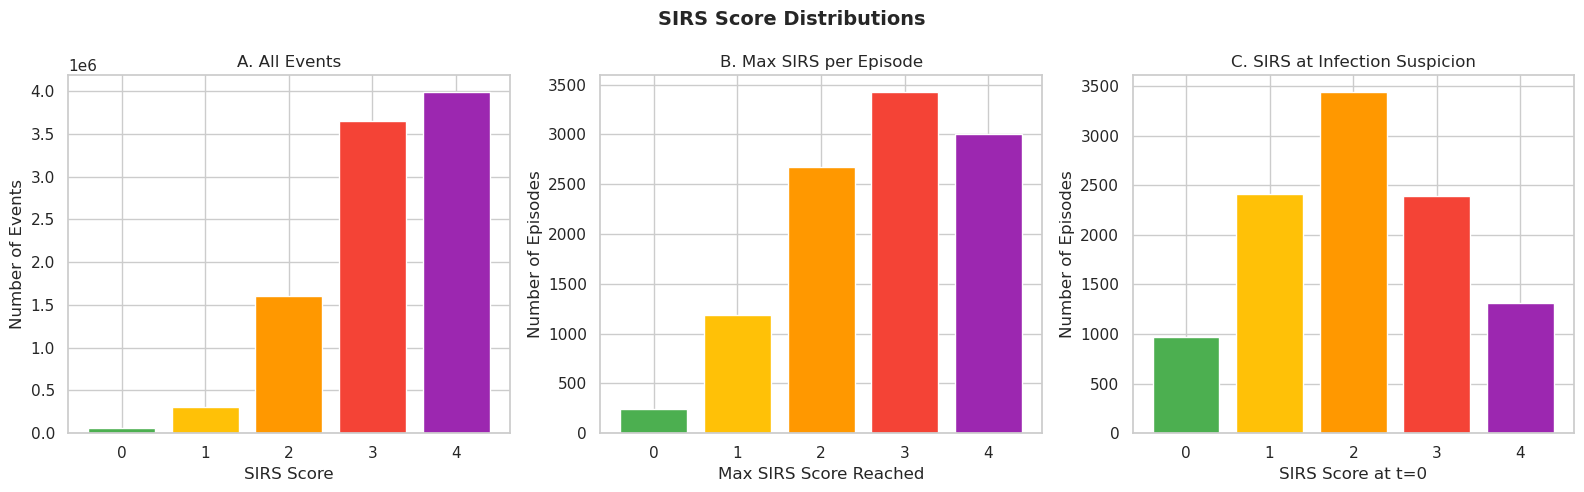

In [44]:
def plot_sirs_distribution(df: pl.DataFrame):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle("SIRS Score Distributions", fontsize=14, fontweight="bold")

    # ── Panel A: Distribution across ALL events ───────────────────
    # This is the unconditional distribution — every measurement,
    # regardless of when in the episode it occurred
    event_counts = (
        df.group_by("sirs_score")
        .agg(pl.len().alias("count"))
        .sort("sirs_score")
    )
    axes[0].bar(
        event_counts["sirs_score"].to_list(),
        event_counts["count"].to_list(),
        color=[SIRS_COLORS[s] for s in event_counts["sirs_score"].to_list()],
        edgecolor="white"
    )
    axes[0].set_title("A. All Events")
    axes[0].set_xlabel("SIRS Score")
    axes[0].set_ylabel("Number of Events")
    axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

    # ── Panel B: Max SIRS score ever reached per episode ──────────
    # This is the severity ceiling — what's the worst each episode got?
    max_sirs = (
        df.group_by("episode_id")
        .agg(pl.col("sirs_score").max().alias("max_sirs"))
        .group_by("max_sirs")
        .agg(pl.len().alias("count"))
        .sort("max_sirs")
    )
    axes[1].bar(
        max_sirs["max_sirs"].to_list(),
        max_sirs["count"].to_list(),
        color=[SIRS_COLORS[s] for s in max_sirs["max_sirs"].to_list()],
        edgecolor="white"
    )
    axes[1].set_title("B. Max SIRS per Episode")
    axes[1].set_xlabel("Max SIRS Score Reached")
    axes[1].set_ylabel("Number of Episodes")
    axes[1].xaxis.set_major_locator(mticker.MultipleLocator(1))

    # ── Panel C: SIRS score at infection suspicion (first event) ──
    # This is the presentation severity — what state was the patient
    # in at the moment infection was flagged?
    first_event_sirs = (
        df.sort(["episode_id", "Event_DateTime"])
        .group_by("episode_id")
        .agg(pl.col("sirs_score").first().alias("first_sirs"))
        .group_by("first_sirs")
        .agg(pl.len().alias("count"))
        .sort("first_sirs")
    )
    axes[2].bar(
        first_event_sirs["first_sirs"].to_list(),
        first_event_sirs["count"].to_list(),
        color=[SIRS_COLORS[s] for s in first_event_sirs["first_sirs"].to_list()],
        edgecolor="white"
    )
    axes[2].set_title("C. SIRS at Infection Suspicion")
    axes[2].set_xlabel("SIRS Score at t=0")
    axes[2].set_ylabel("Number of Episodes")
    axes[2].xaxis.set_major_locator(mticker.MultipleLocator(1))

    plt.tight_layout()
    plt.show()

plot_sirs_distribution(df)

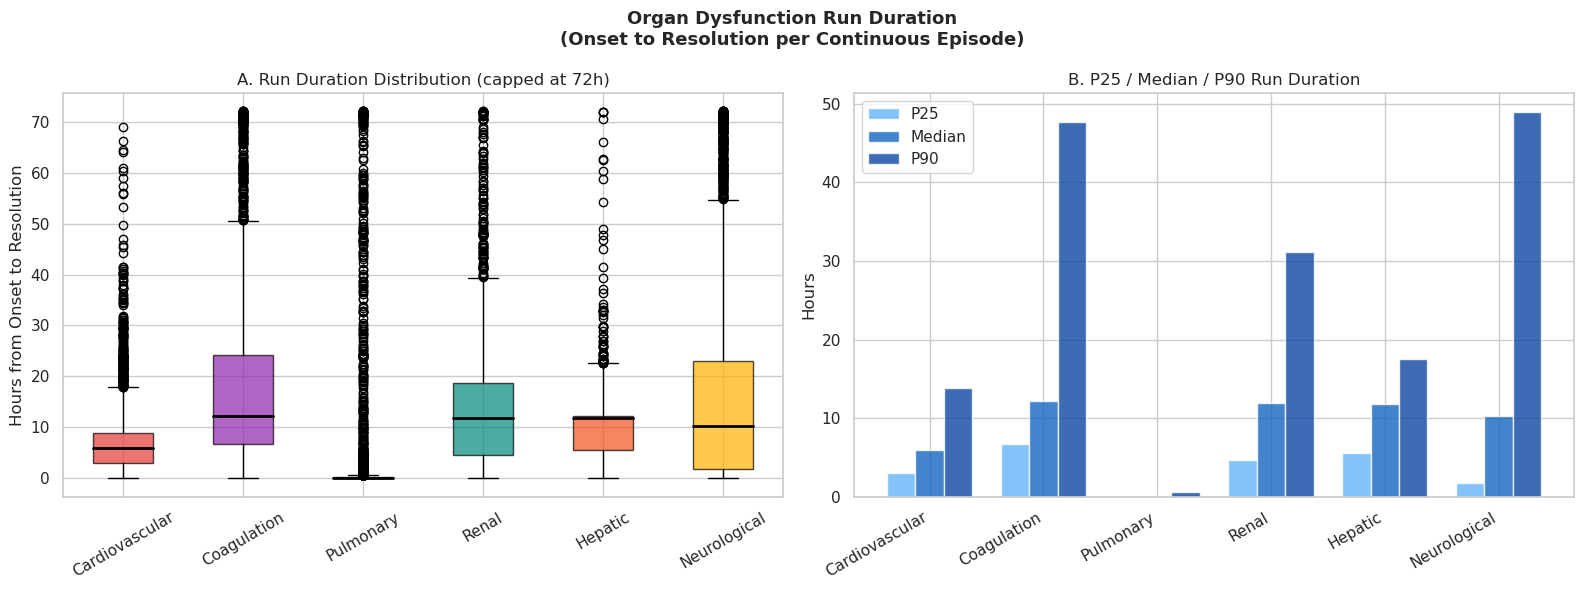


Organ Dysfunction Run Duration Summary:
shape: (6, 6)
┌────────────────┬────────┬────────────┬─────────┬─────────┬─────────┐
│ Organ System   ┆ N Runs ┆ Median (h) ┆ P25 (h) ┆ P75 (h) ┆ P90 (h) │
│ ---            ┆ ---    ┆ ---        ┆ ---     ┆ ---     ┆ ---     │
│ str            ┆ i64    ┆ f64        ┆ f64     ┆ f64     ┆ f64     │
╞════════════════╪════════╪════════════╪═════════╪═════════╪═════════╡
│ Cardiovascular ┆ 3882   ┆ 6.0        ┆ 2.97    ┆ 8.93    ┆ 13.82   │
│ Coagulation    ┆ 2264   ┆ 12.2       ┆ 6.72    ┆ 24.27   ┆ 47.72   │
│ Pulmonary      ┆ 103225 ┆ 0.08       ┆ 0.0     ┆ 0.25    ┆ 0.62    │
│ Renal          ┆ 1931   ┆ 11.87      ┆ 4.67    ┆ 18.62   ┆ 31.17   │
│ Hepatic        ┆ 1467   ┆ 11.77      ┆ 5.5     ┆ 12.32   ┆ 17.48   │
│ Neurological   ┆ 4536   ┆ 10.27      ┆ 1.77    ┆ 22.97   ┆ 48.93   │
└────────────────┴────────┴────────────┴─────────┴─────────┴─────────┘


In [86]:
def compute_dysfunction_run_duration(df: pl.DataFrame, organ: str) -> pl.DataFrame:
    """
    For each organ system, identify contiguous runs of flag=1
    within an episode and compute the total duration of each run.
    """
    df_sorted = df.sort(["episode_id", "Event_DateTime"])

    records = []

    for episode, group in df_sorted.group_by("episode_id"):
        group  = group.sort("Event_DateTime")
        times  = group["Event_DateTime"].to_list()
        flags  = group[organ].to_list()

        # Walk through events and identify contiguous flag=1 runs
        in_run    = False
        run_start = None

        for i, (t, f) in enumerate(zip(times, flags)):
            if f == 1 and not in_run:
                # Dysfunction onset
                in_run    = True
                run_start = t

            elif f == 0 and in_run:
                # Dysfunction resolved
                duration_hours = (t - run_start).total_seconds() / 3600
                records.append({
                    "episode_id":     episode,
                    "organ":          ORGAN_LABELS[organ],
                    "run_start":      run_start,
                    "run_end":        t,
                    "duration_hours": duration_hours
                })
                in_run    = False
                run_start = None

        # If still in a run at end of episode — censored, still include it
        if in_run:
            duration_hours = (times[-1] - run_start).total_seconds() / 3600
            records.append({
                "episode_id":     episode,
                "organ":          ORGAN_LABELS[organ],
                "run_start":      run_start,
                "run_end":        times[-1],
                "duration_hours": duration_hours,
            })

    return pl.DataFrame(records) if records else pl.DataFrame()
def plot_dysfunction_run_durations(df: pl.DataFrame):
    """
    Compute and plot how long each organ dysfunction lasts
    once it starts — this is the clinically meaningful duration.
    """
    all_runs = pl.concat([
        compute_dysfunction_run_duration(df, organ)
        for organ in ORGAN_SYSTEMS
        if df[organ].sum() > 0      # skip organs with no events
    ])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Organ Dysfunction Run Duration\n(Onset to Resolution per Continuous Episode)",
                 fontsize=13, fontweight="bold")

    CAP_HOURS = 72
    stats_rows = []
    data_for_box = {}

    for organ_label in [ORGAN_LABELS[o] for o in ORGAN_SYSTEMS]:
        subset = all_runs.filter(
            (pl.col("organ") == organ_label) &
            (pl.col("duration_hours") <= CAP_HOURS)
        )["duration_hours"]

        if len(subset) == 0:
            continue

        data_for_box[organ_label] = subset.to_list()
        stats_rows.append({
            "Organ System": organ_label,
            "N Runs":       len(subset),
            "Median (h)":   round(float(subset.median()), 2),
            "P25 (h)":      round(float(subset.quantile(0.25)), 2),
            "P75 (h)":      round(float(subset.quantile(0.75)), 2),
            "P90 (h)":      round(float(subset.quantile(0.90)), 2),
        })

    # Panel A: Boxplot
    bp = axes[0].boxplot(
        list(data_for_box.values()),
        labels=list(data_for_box.keys()),
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
    for patch, organ in zip(bp["boxes"], ORGAN_SYSTEMS):
        patch.set_facecolor(ORGAN_COLORS[organ])
        patch.set_alpha(0.7)

    axes[0].set_title(f"A. Run Duration Distribution (capped at {CAP_HOURS}h)")
    axes[0].set_ylabel("Hours from Onset to Resolution")
    axes[0].tick_params(axis='x', rotation=30)

    # Panel B: P25 / Median / P90 grouped bars
    organ_names = [r["Organ System"] for r in stats_rows]
    medians     = [r["Median (h)"]   for r in stats_rows]
    p25         = [r["P25 (h)"]      for r in stats_rows]
    p90         = [r["P90 (h)"]      for r in stats_rows]
    x           = np.arange(len(organ_names))
    width       = 0.25

    axes[1].bar(x - width, p25,     width, label="P25",    alpha=0.8, color="#64B5F6")
    axes[1].bar(x,         medians, width, label="Median", alpha=0.8, color="#1565C0")
    axes[1].bar(x + width, p90,     width, label="P90",    alpha=0.8, color="#0D47A1")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(organ_names, rotation=30, ha="right")
    axes[1].set_ylabel("Hours")
    axes[1].set_title("B. P25 / Median / P90 Run Duration")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    stats_df = pl.DataFrame(stats_rows)
    print("\nOrgan Dysfunction Run Duration Summary:")
    print(stats_df)
    return stats_df, all_runs

run_stats, all_runs = plot_dysfunction_run_durations(df2)


Sojourn Time Summary Table:
shape: (5, 7)
┌────────────┬──────────┬────────────┬─────────┬─────────┬─────────┬─────────┐
│ SIRS State ┆ N Events ┆ Median (h) ┆ P25 (h) ┆ P75 (h) ┆ P90 (h) ┆ Max (h) │
│ ---        ┆ ---      ┆ ---        ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str        ┆ i64      ┆ f64        ┆ f64     ┆ f64     ┆ f64     ┆ f64     │
╞════════════╪══════════╪════════════╪═════════╪═════════╪═════════╪═════════╡
│ SIRS=0     ┆ 4256     ┆ 0.17       ┆ 0.04    ┆ 0.52    ┆ 1.23    ┆ 74.77   │
│ SIRS=1     ┆ 21675    ┆ 0.22       ┆ 0.07    ┆ 0.56    ┆ 1.27    ┆ 651.32  │
│ SIRS=2     ┆ 121425   ┆ 0.25       ┆ 0.08    ┆ 0.7     ┆ 1.5     ┆ 662.5   │
│ SIRS=3     ┆ 282947   ┆ 0.25       ┆ 0.08    ┆ 0.6     ┆ 1.3     ┆ 1184.0  │
│ SIRS=4     ┆ 375085   ┆ 0.24       ┆ 0.08    ┆ 0.43    ┆ 1.0     ┆ 3509.4  │
└────────────┴──────────┴────────────┴─────────┴─────────┴─────────┴─────────┘


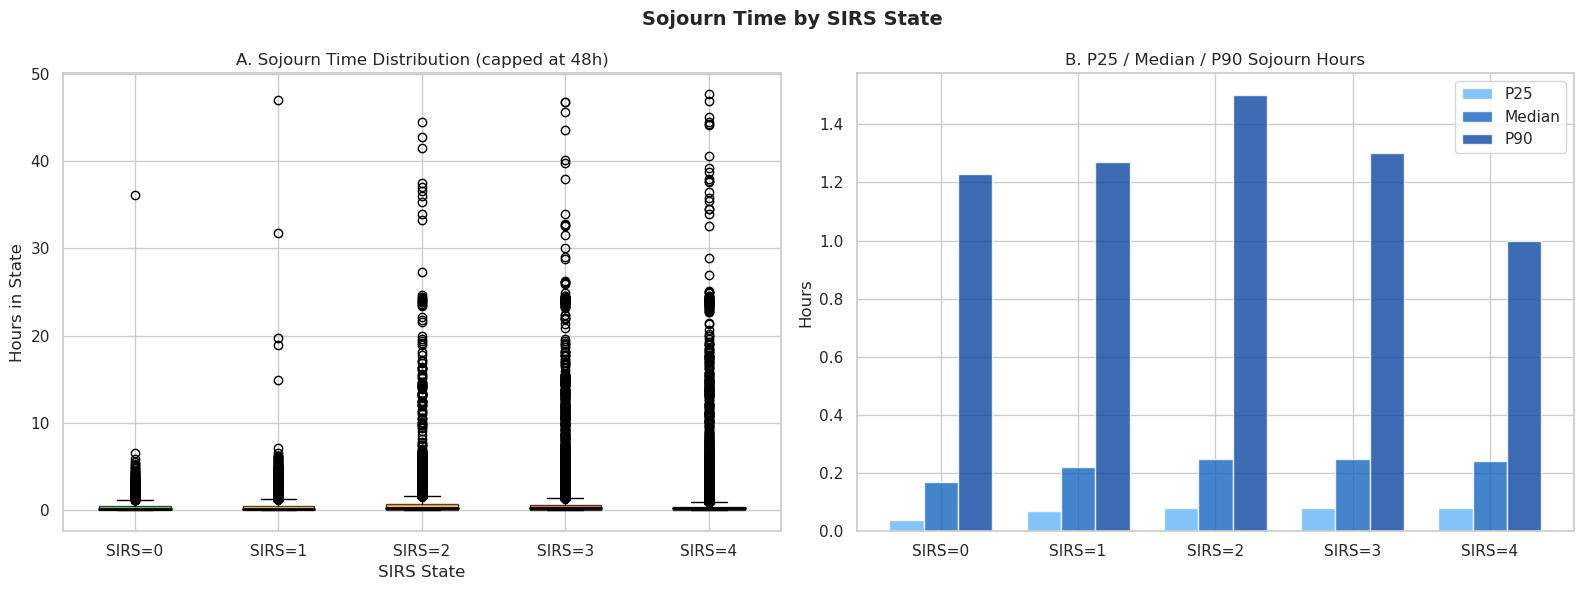

In [ ]:
def compute_sojourn_times(df: pl.DataFrame) -> pl.DataFrame:
    """
    For each event, compute how long the patient stayed in that
    SIRS state before the next event (i.e., the sojourn duration).
    The last event per episode is dropped (no successor to compute
    duration against).
    """
    df_sorted = df.sort(["episode_id", "Event_DateTime"])

    df_sojourn = df_sorted.with_columns([
        # Next event time within the same episode
        pl.col("Event_DateTime")
          .shift(-1)
          .over("episode_id")
          .alias("next_event_dt"),
    ]).with_columns([
        # Duration in hours
        (pl.col("next_event_dt") - pl.col("Event_DateTime"))
          .dt.total_seconds()
          .truediv(3600)
          .alias("sojourn_hours")
    ]).filter(
        # Drop last event per episode (sojourn_hours will be null)
        # and any negative durations (data quality guard)
        pl.col("sojourn_hours").is_not_null() &
        (pl.col("sojourn_hours") > 0)
    )

    return df_sojourn


def plot_sojourn_times(df_sojourn: pl.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Sojourn Time by SIRS State", fontsize=14, fontweight="bold")

    # ── Panel A: Boxplot per SIRS state ───────────────────────────
    # Cap at 48 hours for readability — extreme outliers compress the plot
    CAP_HOURS = 48
    data_for_box = {
        state: df_sojourn
            .filter(
                (pl.col("sirs_score") == state) &
                (pl.col("sojourn_hours") <= CAP_HOURS)
            )["sojourn_hours"].to_list()
        for state in range(5)
        if df_sojourn.filter(pl.col("sirs_score") == state).height > 0
    }

    bp = axes[0].boxplot(
        list(data_for_box.values()),
        labels=[f"SIRS={s}" for s in data_for_box.keys()],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
    for patch, state in zip(bp["boxes"], data_for_box.keys()):
        patch.set_facecolor(SIRS_COLORS[state])
        patch.set_alpha(0.7)

    axes[0].set_title(f"A. Sojourn Time Distribution (capped at {CAP_HOURS}h)")
    axes[0].set_xlabel("SIRS State")
    axes[0].set_ylabel("Hours in State")

    # ── Panel B: Summary statistics table as a heatmap ────────────
    stats_rows = []
    for state in range(5):
        subset = df_sojourn.filter(pl.col("sirs_score") == state)["sojourn_hours"]
        if len(subset) == 0:
            continue
        stats_rows.append({
            "SIRS State": f"SIRS={state}",
            "N Events":   len(subset),
            "Median (h)": round(float(subset.median()), 2),
            "P25 (h)":    round(float(subset.quantile(0.25)), 2),
            "P75 (h)":    round(float(subset.quantile(0.75)), 2),
            "P90 (h)":    round(float(subset.quantile(0.90)), 2),
            "Max (h)":    round(float(subset.max()), 2),
        })

    stats_df = pl.DataFrame(stats_rows)
    print("\nSojourn Time Summary Table:")
    print(stats_df)

    # Plot P25/Median/P90 as grouped bars
    states     = [r["SIRS State"] for r in stats_rows]
    medians    = [r["Median (h)"] for r in stats_rows]
    p25        = [r["P25 (h)"]    for r in stats_rows]
    p90        = [r["P90 (h)"]    for r in stats_rows]
    x          = np.arange(len(states))
    width      = 0.25

    axes[1].bar(x - width, p25,     width, label="P25",    alpha=0.8, color="#64B5F6")
    axes[1].bar(x,         medians, width, label="Median", alpha=0.8, color="#1565C0")
    axes[1].bar(x + width, p90,     width, label="P90",    alpha=0.8, color="#0D47A1")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(states)
    axes[1].set_title("B. P25 / Median / P90 Sojourn Hours")
    axes[1].set_ylabel("Hours")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    return stats_df


df_sojourn = compute_sojourn_times(df)
sojourn_stats = plot_sojourn_times(df_sojourn)

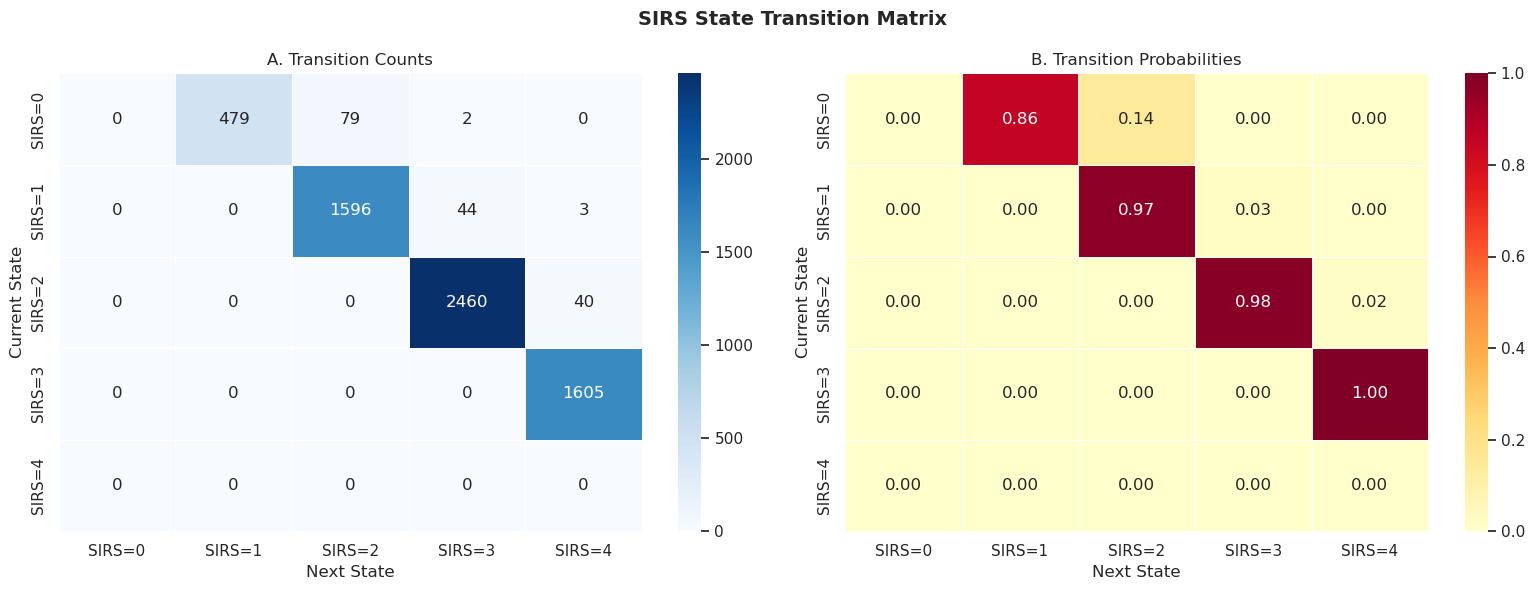


Transition Probability Summary:
From        → SIRS=0  → SIRS=1  → SIRS=2  → SIRS=3  → SIRS=4
SIRS=0        0.00      0.86      0.14      0.00      0.00    (n=560)
SIRS=1        0.00      0.00      0.97      0.03      0.00    (n=1643)
SIRS=2        0.00      0.00      0.00      0.98      0.02    (n=2500)
SIRS=3        0.00      0.00      0.00      0.00      1.00    (n=1605)


In [48]:
# def compute_transition_matrix(df_sojourn: pl.DataFrame):
#     """
#     Build empirical transition probabilities between SIRS states.
#     Uses df_sojourn (which already has the next event lined up).
#     """
#     # Get current and next SIRS score
#     df_sorted = df_sojourn.sort(["episode_id", "Event_DateTime"])

#     transitions = df_sorted.with_columns(
#         pl.col("sirs_score")
#           .shift(-1)
#           .over("episode_id")
#           .alias("next_sirs_score")
#     ).filter(
#         pl.col("next_sirs_score").is_not_null()
#     ).select(["sirs_score", "next_sirs_score"])

#     # Count matrix
#     states = list(range(5))
#     count_matrix = np.zeros((5, 5), dtype=int)

#     for row in transitions.iter_rows():
#         curr, nxt = row
#         count_matrix[curr][nxt] += 1

#     # Normalize rows to get probabilities
#     row_sums = count_matrix.sum(axis=1, keepdims=True)
#     # Avoid division by zero for states with no observations
#     row_sums[row_sums == 0] = 1
#     prob_matrix = count_matrix / row_sums

#     return count_matrix, prob_matrix, states

def compute_transition_matrix(df_sojourn: pl.DataFrame):
    df_sorted = df_sojourn.sort(["episode_id", "Event_DateTime"])

    transitions = df_sorted.with_columns(
        pl.col("sirs_score")
          .shift(-1)
          .over("episode_id")
          .alias("next_sirs_score")
    ).filter(
        pl.col("next_sirs_score").is_not_null()
    ).filter(
        # ── Only keep rows where state actually changed ───────────
        pl.col("sirs_score") != pl.col("next_sirs_score")
    ).select(["sirs_score", "next_sirs_score"])

    # Rest is identical
    states = list(range(5))
    count_matrix = np.zeros((5, 5), dtype=int)

    for row in transitions.iter_rows():
        curr, nxt = row
        count_matrix[curr][nxt] += 1

    row_sums = count_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    prob_matrix = count_matrix / row_sums

    return count_matrix, prob_matrix, states


def plot_transition_matrix(count_matrix, prob_matrix, states):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("SIRS State Transition Matrix", fontsize=14, fontweight="bold")

    labels = [f"SIRS={s}" for s in states]

    # ── Panel A: Raw counts ───────────────────────────────────────
    sns.heatmap(
        count_matrix,
        annot=True, fmt="d",
        xticklabels=labels, yticklabels=labels,
        cmap="Blues", ax=axes[0],
        linewidths=0.5
    )
    axes[0].set_title("A. Transition Counts")
    axes[0].set_xlabel("Next State")
    axes[0].set_ylabel("Current State")

    # ── Panel B: Transition probabilities ─────────────────────────
    sns.heatmap(
        prob_matrix,
        annot=True, fmt=".2f",
        xticklabels=labels, yticklabels=labels,
        cmap="YlOrRd", ax=axes[1],
        linewidths=0.5,
        vmin=0, vmax=1
    )
    axes[1].set_title("B. Transition Probabilities")
    axes[1].set_xlabel("Next State")
    axes[1].set_ylabel("Current State")

    plt.tight_layout()
    plt.show()

    # Print readable summary for clinical leadership
    print("\nTransition Probability Summary:")
    print(f"{'From':<10}", end="")
    for s in states:
        print(f"  → SIRS={s}", end="")
    print()
    for i, row in enumerate(prob_matrix):
        if count_matrix[i].sum() == 0:
            continue
        print(f"SIRS={i:<5}", end="")
        for p in row:
            print(f"    {p:.2f}  ", end="")
        print(f"  (n={count_matrix[i].sum()})")


count_matrix, prob_matrix, states = compute_transition_matrix(df_sojourn)
plot_transition_matrix(count_matrix, prob_matrix, states)

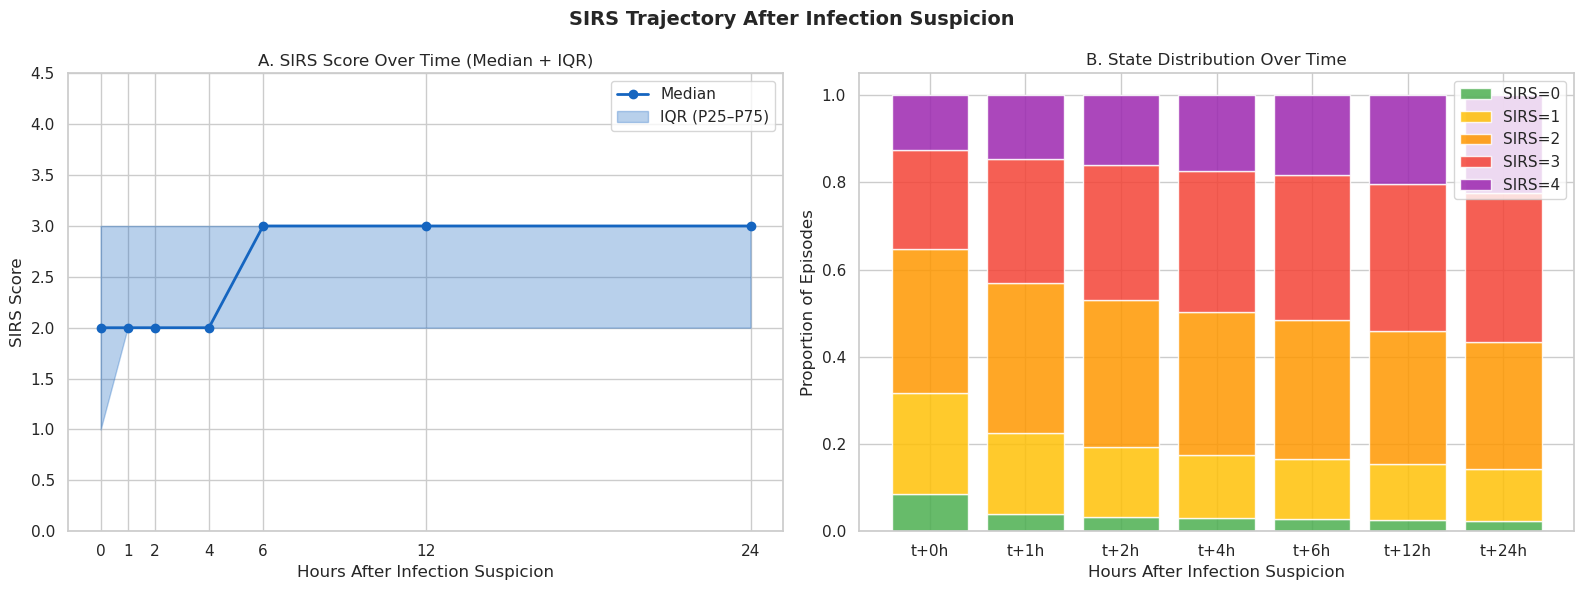


Median SIRS Score at Each Timepoint:
shape: (7, 4)
┌───────────┬────────┬─────┬─────┐
│ timepoint ┆ median ┆ p25 ┆ p75 │
│ ---       ┆ ---    ┆ --- ┆ --- │
│ i64       ┆ f64    ┆ f64 ┆ f64 │
╞═══════════╪════════╪═════╪═════╡
│ 0         ┆ 2.0    ┆ 1.0 ┆ 3.0 │
│ 1         ┆ 2.0    ┆ 2.0 ┆ 3.0 │
│ 2         ┆ 2.0    ┆ 2.0 ┆ 3.0 │
│ 4         ┆ 2.0    ┆ 2.0 ┆ 3.0 │
│ 6         ┆ 3.0    ┆ 2.0 ┆ 3.0 │
│ 12        ┆ 3.0    ┆ 2.0 ┆ 3.0 │
│ 24        ┆ 3.0    ┆ 2.0 ┆ 3.0 │
└───────────┴────────┴─────┴─────┘


In [ ]:
def plot_sirs_trajectory(df: pl.DataFrame):
    """
    At fixed timepoints after infection suspicion, what is the
    distribution of SIRS scores? Uses last-value-carried-forward.
    """
    TIMEPOINTS_HOURS = [0, 1, 2, 4, 6, 12, 24]

    # Time since infection suspicion for each event
    df = df.with_columns(
        ((pl.col("Event_DateTime") - pl.col("episode_start"))
         .dt.total_seconds()
         .truediv(3600))
        .alias("hours_since_suspicion")
    )

    records = []
    for episode, group in df.sort("Event_DateTime").group_by("episode_id"):
        group = group.sort("hours_since_suspicion")
        times  = group["hours_since_suspicion"].to_list()
        scores = group["sirs_score"].to_list()

        for tp in TIMEPOINTS_HOURS:
            # Find the most recent event at or before this timepoint
            # (last value carried forward)
            candidates = [(t, s) for t, s in zip(times, scores) if t <= tp]
            if candidates:
                sirs_at_tp = candidates[-1][1]   # last one before/at timepoint
                records.append({"timepoint": tp, "sirs_score": sirs_at_tp})

    traj_df = pl.DataFrame(records)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("SIRS Trajectory After Infection Suspicion", fontsize=14, fontweight="bold")

    # ── Panel A: Median + IQR band over time ──────────────────────
    stats = (
        traj_df.group_by("timepoint")
        .agg([
            pl.col("sirs_score").median().alias("median"),
            pl.col("sirs_score").quantile(0.25).alias("p25"),
            pl.col("sirs_score").quantile(0.75).alias("p75"),
            pl.col("sirs_score").mean().alias("mean"),
        ])
        .sort("timepoint")
    )

    tps      = stats["timepoint"].to_list()
    medians  = stats["median"].to_list()
    p25      = stats["p25"].to_list()
    p75      = stats["p75"].to_list()

    axes[0].plot(tps, medians, marker="o", color="#1565C0", linewidth=2, label="Median")
    axes[0].fill_between(tps, p25, p75, alpha=0.3, color="#1565C0", label="IQR (P25–P75)")
    axes[0].set_xticks(TIMEPOINTS_HOURS)
    axes[0].set_xlabel("Hours After Infection Suspicion")
    axes[0].set_ylabel("SIRS Score")
    axes[0].set_title("A. SIRS Score Over Time (Median + IQR)")
    axes[0].legend()
    axes[0].set_ylim(0, 4.5)

    # ── Panel B: Stacked area — proportion in each state at each tp
    pivot = (
        traj_df.with_columns(pl.col("sirs_score").cast(pl.Utf8))
        .group_by(["timepoint", "sirs_score"])
        .agg(pl.len().alias("count"))
        .sort(["timepoint", "sirs_score"])
    )

    # Build proportion matrix: rows = timepoints, cols = SIRS 0–4
    tp_list = sorted(traj_df["timepoint"].unique().to_list())
    prop_matrix = np.zeros((len(tp_list), 5))

    for i, tp in enumerate(tp_list):
        tp_data = pivot.filter(pl.col("timepoint") == tp)
        total   = tp_data["count"].sum()
        for row in tp_data.iter_rows(named=True):
            state = int(row["sirs_score"])
            prop_matrix[i][state] = row["count"] / total

    bottom = np.zeros(len(tp_list))
    for state in range(5):
        axes[1].bar(
            range(len(tp_list)),
            prop_matrix[:, state],
            bottom=bottom,
            color=SIRS_COLORS[state],
            label=f"SIRS={state}",
            alpha=0.85
        )
        bottom += prop_matrix[:, state]

    axes[1].set_xticks(range(len(tp_list)))
    axes[1].set_xticklabels([f"t+{h}h" for h in tp_list])
    axes[1].set_xlabel("Hours After Infection Suspicion")
    axes[1].set_ylabel("Proportion of Episodes")
    axes[1].set_title("B. State Distribution Over Time")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    print("\nMedian SIRS Score at Each Timepoint:")
    print(stats.select(["timepoint", "median", "p25", "p75"]))


plot_sirs_trajectory(df)def plot_sirs_trajectory(df: pl.DataFrame):
    """
    At fixed timepoints after infection suspicion, what is the
    distribution of SIRS scores? Uses last-value-carried-forward.
    """
    TIMEPOINTS_HOURS = [0, 1, 2, 4, 6, 12, 24]

    # Time since infection suspicion for each event
    df = df.with_columns(
        ((pl.col("Event_DateTime") - pl.col("episode_start"))
         .dt.total_seconds()
         .truediv(3600))
        .alias("hours_since_suspicion")
    )

    records = []
    for episode, group in df.sort("Event_DateTime").group_by("episode_id"):
        group = group.sort("hours_since_suspicion")
        times  = group["hours_since_suspicion"].to_list()
        scores = group["sirs_score"].to_list()

        for tp in TIMEPOINTS_HOURS:
            # Find the most recent event at or before this timepoint
            # (last value carried forward)
            candidates = [(t, s) for t, s in zip(times, scores) if t <= tp]
            if candidates:
                sirs_at_tp = candidates[-1][1]   # last one before/at timepoint
                records.append({"timepoint": tp, "sirs_score": sirs_at_tp})

    traj_df = pl.DataFrame(records)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("SIRS Trajectory After Infection Suspicion", fontsize=14, fontweight="bold")

    # ── Panel A: Median + IQR band over time ──────────────────────
    stats = (
        traj_df.group_by("timepoint")
        .agg([
            pl.col("sirs_score").median().alias("median"),
            pl.col("sirs_score").quantile(0.25).alias("p25"),
            pl.col("sirs_score").quantile(0.75).alias("p75"),
            pl.col("sirs_score").mean().alias("mean"),
        ])
        .sort("timepoint")
    )

    tps      = stats["timepoint"].to_list()
    medians  = stats["median"].to_list()
    p25      = stats["p25"].to_list()
    p75      = stats["p75"].to_list()

    axes[0].plot(tps, medians, marker="o", color="#1565C0", linewidth=2, label="Median")
    axes[0].fill_between(tps, p25, p75, alpha=0.3, color="#1565C0", label="IQR (P25–P75)")
    axes[0].set_xticks(TIMEPOINTS_HOURS)
    axes[0].set_xlabel("Hours After Infection Suspicion")
    axes[0].set_ylabel("SIRS Score")
    axes[0].set_title("A. SIRS Score Over Time (Median + IQR)")
    axes[0].legend()
    axes[0].set_ylim(0, 4.5)

    # ── Panel B: Stacked area — proportion in each state at each tp
    pivot = (
        traj_df.with_columns(pl.col("sirs_score").cast(pl.Utf8))
        .group_by(["timepoint", "sirs_score"])
        .agg(pl.len().alias("count"))
        .sort(["timepoint", "sirs_score"])
    )

    # Build proportion matrix: rows = timepoints, cols = SIRS 0–4
    tp_list = sorted(traj_df["timepoint"].unique().to_list())
    prop_matrix = np.zeros((len(tp_list), 5))

    for i, tp in enumerate(tp_list):
        tp_data = pivot.filter(pl.col("timepoint") == tp)
        total   = tp_data["count"].sum()
        for row in tp_data.iter_rows(named=True):
            state = int(row["sirs_score"])
            prop_matrix[i][state] = row["count"] / total

    bottom = np.zeros(len(tp_list))
    for state in range(5):
        axes[1].bar(
            range(len(tp_list)),
            prop_matrix[:, state],
            bottom=bottom,
            color=SIRS_COLORS[state],
            label=f"SIRS={state}",
            alpha=0.85
        )
        bottom += prop_matrix[:, state]

    axes[1].set_xticks(range(len(tp_list)))
    axes[1].set_xticklabels([f"t+{h}h" for h in tp_list])
    axes[1].set_xlabel("Hours After Infection Suspicion")
    axes[1].set_ylabel("Proportion of Episodes")
    axes[1].set_title("B. State Distribution Over Time")
    axes[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()

    print("\nMedian SIRS Score at Each Timepoint:")
    print(stats.select(["timepoint", "median", "p25", "p75"]))


plot_sirs_trajectory(df)

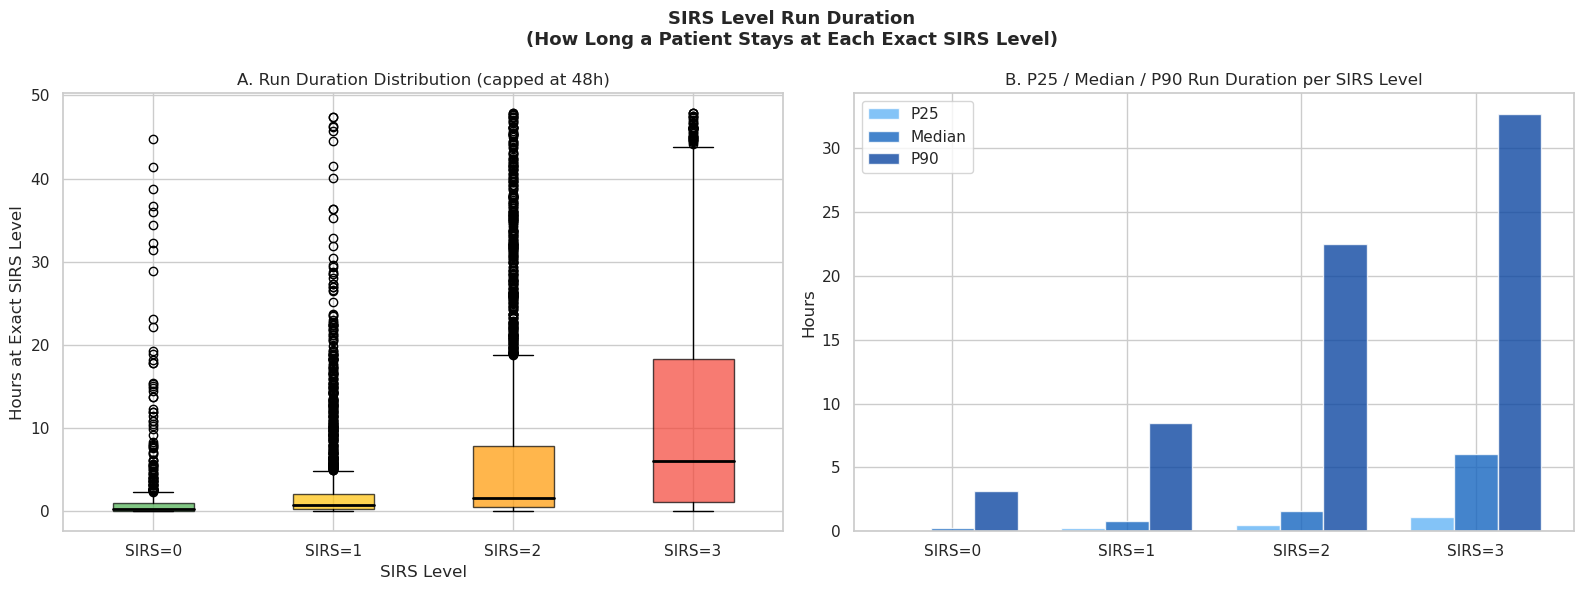


SIRS Run Duration Summary (censored runs excluded from stats):
shape: (4, 7)
┌────────────┬────────┬────────────┬────────────┬─────────┬─────────┬─────────┐
│ SIRS Level ┆ N Runs ┆ N Censored ┆ Median (h) ┆ P25 (h) ┆ P75 (h) ┆ P90 (h) │
│ ---        ┆ ---    ┆ ---        ┆ ---        ┆ ---     ┆ ---     ┆ ---     │
│ str        ┆ i64    ┆ i64        ┆ f64        ┆ f64     ┆ f64     ┆ f64     │
╞════════════╪════════╪════════════╪════════════╪═════════╪═════════╪═════════╡
│ SIRS=0     ┆ 723    ┆ 243        ┆ 0.23       ┆ 0.03    ┆ 0.95    ┆ 3.18    │
│ SIRS=1     ┆ 1918   ┆ 1186       ┆ 0.82       ┆ 0.27    ┆ 2.13    ┆ 8.48    │
│ SIRS=2     ┆ 2533   ┆ 2672       ┆ 1.62       ┆ 0.52    ┆ 7.82    ┆ 22.53   │
│ SIRS=3     ┆ 1441   ┆ 3421       ┆ 6.03       ┆ 1.15    ┆ 18.25   ┆ 32.67   │
└────────────┴────────┴────────────┴────────────┴─────────┴─────────┴─────────┘


In [87]:
def compute_sirs_run_duration(df: pl.DataFrame, sirs_level: int) -> pl.DataFrame:
    """
    For a given SIRS level, identify contiguous runs where
    sirs_score == sirs_level within an episode and compute
    the total duration of each run.
    """
    df_sorted = df.sort(["episode_id", "Event_DateTime"])
    records   = []

    for episode, group in df_sorted.group_by("episode_id"):
        group  = group.sort("Event_DateTime")
        times  = group["Event_DateTime"].to_list()
        scores = group["sirs_score"].to_list()

        in_run    = False
        run_start = None

        for i, (t, s) in enumerate(zip(times, scores)):
            if s == sirs_level and not in_run:
                # Entered this SIRS level
                in_run    = True
                run_start = t

            elif s != sirs_level and in_run:
                # Left this SIRS level
                duration_hours = (t - run_start).total_seconds() / 3600
                records.append({
                    "episode_id":     episode,
                    "sirs_level":     sirs_level,
                    "run_start":      run_start,
                    "run_end":        t,
                    "duration_hours": duration_hours,
                    "censored":       False
                })
                in_run    = False
                run_start = None

        # Still in run at end of episode — censored
        if in_run:
            duration_hours = (times[-1] - run_start).total_seconds() / 3600
            records.append({
                "episode_id":     episode,
                "sirs_level":     sirs_level,
                "run_start":      run_start,
                "run_end":        times[-1],
                "duration_hours": duration_hours,
                "censored":       True      # never resolved within observation window
            })

    return pl.DataFrame(records) if records else pl.DataFrame()


def plot_sirs_run_durations(df: pl.DataFrame):
    """
    Compute and plot how long a patient stays at each exact
    SIRS level before transitioning to any other level.
    """
    # Compute runs for all SIRS levels that exist in the data
    sirs_levels = sorted(df["sirs_score"].unique().to_list())

    all_runs = pl.concat([
        compute_sirs_run_duration(df, level)
        for level in sirs_levels
    ])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(
        "SIRS Level Run Duration\n(How Long a Patient Stays at Each Exact SIRS Level)",
        fontsize=13, fontweight="bold"
    )

    CAP_HOURS  = 48
    stats_rows = []
    data_for_box = {}

    for level in sirs_levels:
        # Exclude censored runs from duration stats — they are
        # lower bounds, not true durations, and would inflate estimates
        subset = all_runs.filter(
            (pl.col("sirs_level") == level) &
            (pl.col("censored")   == False) &
            (pl.col("duration_hours") <= CAP_HOURS)
        )["duration_hours"]

        if len(subset) == 0:
            continue

        label = f"SIRS={level}"
        data_for_box[label] = subset.to_list()

        # Count censored separately — useful context for leadership
        n_censored = all_runs.filter(
            (pl.col("sirs_level") == level) &
            (pl.col("censored")   == True)
        ).height

        stats_rows.append({
            "SIRS Level":   label,
            "N Runs":       len(subset),
            "N Censored":   n_censored,
            "Median (h)":   round(float(subset.median()), 2),
            "P25 (h)":      round(float(subset.quantile(0.25)), 2),
            "P75 (h)":      round(float(subset.quantile(0.75)), 2),
            "P90 (h)":      round(float(subset.quantile(0.90)), 2),
        })

    # ── Panel A: Boxplot ──────────────────────────────────────────
    bp = axes[0].boxplot(
        list(data_for_box.values()),
        labels=list(data_for_box.keys()),
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
    for patch, level in zip(bp["boxes"], sirs_levels):
        patch.set_facecolor(SIRS_COLORS[level])
        patch.set_alpha(0.7)

    axes[0].set_title(f"A. Run Duration Distribution (capped at {CAP_HOURS}h)")
    axes[0].set_ylabel("Hours at Exact SIRS Level")
    axes[0].set_xlabel("SIRS Level")

    # ── Panel B: P25 / Median / P90 grouped bars ─────────────────
    level_names = [r["SIRS Level"] for r in stats_rows]
    medians     = [r["Median (h)"] for r in stats_rows]
    p25         = [r["P25 (h)"]    for r in stats_rows]
    p90         = [r["P90 (h)"]    for r in stats_rows]
    x           = np.arange(len(level_names))
    width       = 0.25

    axes[1].bar(x - width, p25,     width, label="P25",    alpha=0.8, color="#64B5F6")
    axes[1].bar(x,         medians, width, label="Median", alpha=0.8, color="#1565C0")
    axes[1].bar(x + width, p90,     width, label="P90",    alpha=0.8, color="#0D47A1")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(level_names)
    axes[1].set_ylabel("Hours")
    axes[1].set_title("B. P25 / Median / P90 Run Duration per SIRS Level")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    stats_df = pl.DataFrame(stats_rows)
    print("\nSIRS Run Duration Summary (censored runs excluded from stats):")
    print(stats_df)
    return stats_df, all_runs


sirs_run_stats, sirs_all_runs = plot_sirs_run_durations(df)